#                         SIG742 MDS End term Assessment_Team - 59

### Student Id : 225528951, 225453415 & 225440413
### Student Name : DEEPA A, TSERING GYALTSEN & VENKATA SUBRAMANIAN J

Attented High Distinctions Questions : Yes

# PART - **1**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
import zipfile
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import textwrap
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
# Initialize PySpark session
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, to_date, from_unixtime, count,
    isnan, isnull, desc, asc, regexp_replace,
    lower, split, explode, trim
)
from pyspark.sql.types import *

# Create Spark session with optimized configuration for Colab
spark = SparkSession.builder \
    .appName("SIT742_BusinessReview_Analysis") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")
print("Spark session initialized successfully!")

Spark Version: 3.5.1
Spark session initialized successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/business_review_submission.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/business_review_data')

In [ ]:
###Read the File using Pandas
review_df_pd = pd.read_csv('/content/drive/MyDrive/business_review_data/review.csv')
meta_df_pd = pd.read_csv('/content/drive/MyDrive/business_review_data/meta-review-business.csv')

In [ ]:
###Read the File using PySpark
review_df = spark.read.csv('/content/drive/MyDrive/business_review_data/review.csv', header=True, inferSchema=True)
meta_df = spark.read.csv('/content/drive/MyDrive/business_review_data/meta-review-business.csv', header=True, inferSchema=True)
# Display the schema and the first few rows
review_df.printSchema()
review_df.show(5)

root
 |-- user_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- time: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- text: string (nullable = true)
 |-- pics: string (nullable = true)
 |-- resp: string (nullable = true)
 |-- gmap_id: string (nullable = true)

+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+
|             user_id|                name|         time|              rating|                text|pics|resp|             gmap_id|
+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+
|1.091298048426862...|          Nicki Gore|1566331951619|                   5|We always stay he...|NULL|NULL|0x56b646ed2220b77...|
|1.132409264057589...|       Allen Ratliff|1504917982385|                   5|Great campground ...|NULL|NULL|0x56b646ed2220b77...|
|1.130448378911412...|   Jonathan Tringali|

In [ ]:
meta_df.printSchema()
meta_df.show(5)

root
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- gmap_id: string (nullable = true)
 |-- description: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- category: string (nullable = true)
 |-- avg_rating: string (nullable = true)
 |-- num_of_reviews: string (nullable = true)
 |-- price: string (nullable = true)
 |-- hours: string (nullable = true)
 |-- MISC: string (nullable = true)
 |-- state: string (nullable = true)
 |-- relative_results: string (nullable = true)
 |-- url: string (nullable = true)

+--------------------+--------------------+--------------------+-----------+------------------+-------------------+--------------------+----------+--------------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+
|                name|             address|             gmap_id|description|          latitude|          longitude|         

Part 1: Business Review Data Analysis

Question 1.1: Data Wrangling with PySpark
---
Objective: Clean the review data by handling null values in text column and converting time format.

In [ ]:
# Question 1.1.1: Replace null/None in 'text' column with 'no review'
print("=== Question 1.1.1: Handling Null Values in Text Column ===")

# Check initial null count
null_count_before = review_df.filter(col('text').isNull()).count()
print(f"Null values in 'text' column before cleaning: {null_count_before}")

# Replace null/None values with 'no review'
# Using when() function to handle multiple null conditions
review_df_clean = review_df.withColumn(
    'text',
    when(
        col('text').isNull() |
        (col('text') == '') |
        (col('text').isin(['None', 'none', 'null', 'NULL'])),
        'no review'
    ).otherwise(col('text'))
)

# Verify the cleaning
null_count_after = review_df_clean.filter(col('text').isNull()).count()
no_review_count = review_df_clean.filter(col('text') == 'no review').count()

print(f"Null values in 'text' column after cleaning: {null_count_after}")
print(f"Number of 'no review' entries: {no_review_count}")
print("\nSample of cleaned text column:")
review_df_clean.select('text').show(10, truncate=False)

=== Question 1.1.1: Handling Null Values in Text Column ===
Null values in 'text' column before cleaning: 249931
Null values in 'text' column after cleaning: 0
Number of 'no review' entries: 249931

Sample of cleaned text column:
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text                                                                                                                                                                                                                                                                                                                                          |
+-----------------------------------------------------------------------------------------------

In [ ]:
# Question 1.1.2: Convert 'time' string to yyyy-mm-dd format and create 'newtime' column
print("\n=== Question 1.1.2: Time Format Conversion ===")

# Display original time format
print("Original time format (timestamp):")
review_df_clean.select('time').show(5)

# Convert Unix timestamp to date format (yyyy-mm-dd)
# from_unixtime() converts timestamp to datetime, to_date() extracts date part
review_df_clean = review_df_clean.withColumn(
    'newtime',
    to_date(from_unixtime(col('time').cast('bigint')), 'yyyy-MM-dd')
)

# Display the results
print("\nConverted time format (newtime column):")
review_df_clean.select('time', 'newtime').show(5)

# Show first 5 rows with text and time columns as requested
print("\nFirst 5 rows showing text, time, and newtime columns:")
review_df_clean.select('text', 'time', 'newtime').show(5, truncate=False)

# Cache the cleaned dataframe for better performance in subsequent operations
review_df_clean.cache()
print(f"\nDataFrame cached. Total rows after cleaning: {review_df_clean.count()}")


=== Question 1.1.2: Time Format Conversion ===
Original time format (timestamp):
+-------------+
|         time|
+-------------+
|1566331951619|
|1504917982385|
|1474765901185|
|       toilet|
|         NULL|
+-------------+
only showing top 5 rows


Converted time format (newtime column):
+-------------+-----------+
|         time|    newtime|
+-------------+-----------+
|1566331951619|51605-01-31|
|1504917982385|49658-12-14|
|1474765901185|48703-06-22|
|       toilet|       NULL|
|         NULL|       NULL|
+-------------+-----------+
only showing top 5 rows


First 5 rows showing text, time, and newtime columns:
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+-----------+
|text                                                            

Question 1.2: Review Counts and Time Analysis
---
Objective: Analyze review patterns by business and time, then create visualizations.

In [ ]:
# Question 1.2.1: Calculate number of reviews per gmap_id as float
print("=== Question 1.2.1: Review Counts per Business ===")

# Group by gmap_id and count reviews, cast to float as requested
reviews_per_gmap = review_df_clean.groupBy('gmap_id') \
    .agg(count('*').cast('float').alias('review_count')) \
    .orderBy(desc('review_count'))

print("Top 5 businesses by review count:")
reviews_per_gmap.show(5)

# Get some statistics about review distribution
review_stats = reviews_per_gmap.select('review_count').describe()
print("\nReview count statistics:")
review_stats.show()

=== Question 1.2.1: Review Counts per Business ===
Top 5 businesses by review count:
+--------------------+------------+
|             gmap_id|review_count|
+--------------------+------------+
|                NULL|     46309.0|
|0x56c897b9ce6000d...|      2737.0|
|0x56c899d05892048...|      2555.0|
|0x56c897c63697ee3...|      2220.0|
|0x56c8965ee2fb87a...|      2202.0|
+--------------------+------------+
only showing top 5 rows


Review count statistics:
+-------+-----------------+
|summary|     review_count|
+-------+-----------------+
|  count|            12468|
|   mean|44.32338787295476|
| stddev|430.5404976132112|
|    min|              1.0|
|    max|          46309.0|
+-------+-----------------+



In [ ]:
# Question 1.2.2: Transform to Pandas and create review_time (hour) column
print("=== Question 1.2.2: PySpark to Pandas Conversion ===")

from pyspark.sql.functions import col

# 1) Join reviews, metadata, and counts, but exclude the Spark newtime
reviews_alias = review_df_clean.alias("r")
meta_alias    = meta_df.select("gmap_id", "name", "category").alias("m")

joined_meta = reviews_alias.join(
    meta_alias,
    on=col("r.gmap_id") == col("m.gmap_id"),
    how="left"
)

safe_spark_df = joined_meta.join(
    reviews_per_gmap.alias("c"),
    on=col("r.gmap_id") == col("c.gmap_id"),
    how="left"
).select(
    col("r.gmap_id").alias("gmap_id"),
    col("r.time").alias("time"),         # raw UNIX ms timestamp
    col("r.rating").alias("rating"),
    col("r.text").alias("text"),
    col("c.review_count").alias("review_count"),
    col("m.name").alias("business_name"),
    col("m.category").alias("category")
)

# 2) Convert to Pandas
df = safe_spark_df.toPandas()
print(f"Pandas DataFrame shape: {df.shape}")

# 3) Create newtime in Pandas from the raw millisecond timestamp
import pandas as pd
df['newtime'] = pd.to_datetime(df['time'], unit='ms', errors='coerce')
valid_count = df['newtime'].notna().sum()
print(f"Rows with valid newtime: {valid_count} / {len(df)}")

# 4) Drop rows where conversion failed
df = df.dropna(subset=['newtime'])
print(f"After dropping invalid dates: {df.shape}")

# 5) Extract the hour component
df['review_time'] = df['newtime'].dt.hour

# 6) Display results
print("\nTop 5 rows after creating review_time column:")
print(df[['gmap_id', 'business_name', 'category', 'newtime', 'review_time', 'review_count']].head())

print(f"\nReview time (hour) range: {df['review_time'].min()} to {df['review_time'].max()}")
print("Most common review hours:")
print(df['review_time'].value_counts().head())

=== Question 1.2.2: PySpark to Pandas Conversion ===
Pandas DataFrame shape: (553076, 7)
Rows with valid newtime: 521972 / 553076
After dropping invalid dates: (521972, 8)

Top 5 rows after creating review_time column:
                                 gmap_id                business_name  \
0  0x56b646ed2220b77f:0xd8975e316de80952  Bear Creek Cabins & RV Park   
1  0x56b646ed2220b77f:0xd8975e316de80952  Bear Creek Cabins & RV Park   
2  0x56b646ed2220b77f:0xd8975e316de80952  Bear Creek Cabins & RV Park   
3  0x56b646ed2220b77f:0xd8975e316de80952  Bear Creek Cabins & RV Park   
4                                   None                         None   

                                           category                 newtime  \
0  ['RV park', 'Cabin rental agency', 'Campground'] 2019-08-20 20:12:31.619   
1  ['RV park', 'Cabin rental agency', 'Campground'] 2019-08-20 20:12:31.619   
2  ['RV park', 'Cabin rental agency', 'Campground'] 2017-09-09 00:46:22.385   
3  ['RV park', 'Cabin rent

=== Question 1.2.3: Time-based Review Visualizations ===


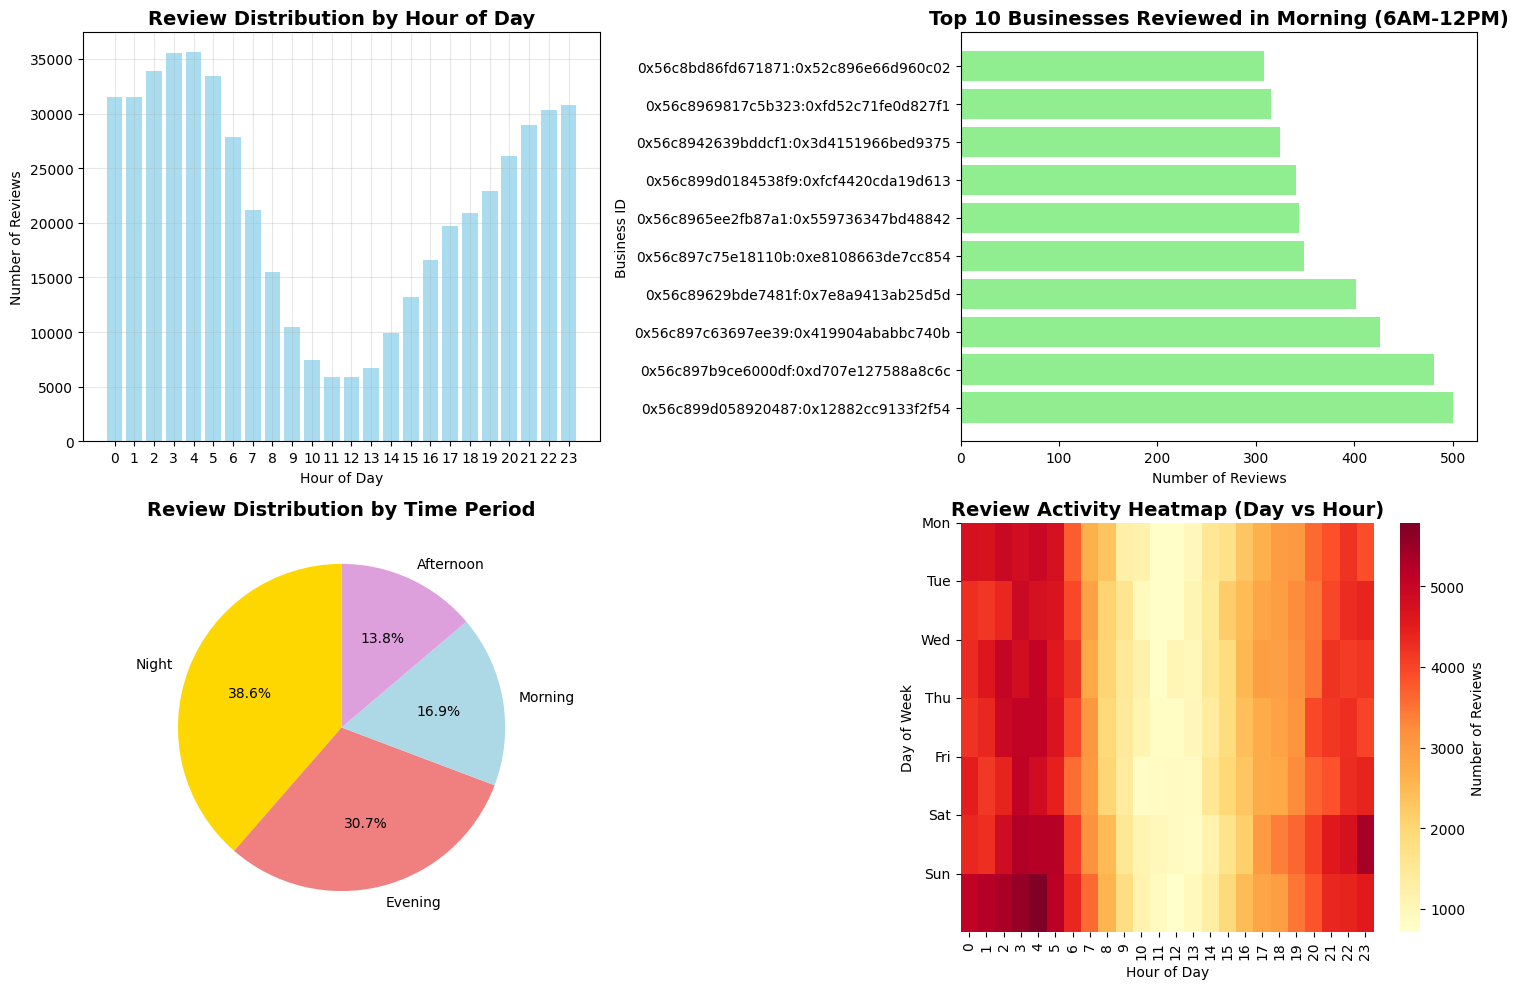


=== Key Insights from Visualizations ===
• Peak review hour: 4:00 with 35646 reviews
• Total morning reviews (6AM-12PM): 88455
• Most active time period: Night (201473 reviews)
• Number of businesses reviewed in morning: 6732
• Average reviews per business in morning: 13.14


In [ ]:
# Question 1.2.3: Visualizations on relationship between gmap_id and review_time
print("=== Question 1.2.3: Time-based Review Visualizations ===")

# Set up the plotting environment
plt.style.use('default')
fig = plt.figure(figsize=(15, 10))

# Visualization 1: Review distribution by hour of day
plt.subplot(2, 2, 1)
hourly_reviews = df.groupby('review_time').size()
plt.bar(hourly_reviews.index, hourly_reviews.values, color='skyblue', alpha=0.7)
plt.title('Review Distribution by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Reviews')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

# Visualization 2: Top businesses reviewed in morning hours (6-12)
plt.subplot(2, 2, 2)
morning_reviews = df[(df['review_time'] >= 6) & (df['review_time'] < 12)]
top_morning_businesses = morning_reviews.groupby('gmap_id').size().sort_values(ascending=False).head(10)

plt.barh(range(len(top_morning_businesses)), top_morning_businesses.values, color='lightgreen')
plt.yticks(range(len(top_morning_businesses)), top_morning_businesses.index)
plt.title('Top 10 Businesses Reviewed in Morning (6AM-12PM)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Business ID')

# Visualization 3: Review patterns by time periods
plt.subplot(2, 2, 3)
# Define time periods
def get_time_period(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df['time_period'] = df['review_time'].apply(get_time_period)
period_counts = df['time_period'].value_counts()

colors = ['gold', 'lightcoral', 'lightblue', 'plum']
plt.pie(period_counts.values, labels=period_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Review Distribution by Time Period', fontsize=14, fontweight='bold')

# Visualization 4: Business activity heatmap (hour vs day of week)
plt.subplot(2, 2, 4)
df['day_of_week'] = df['newtime'].dt.day_name()
df['weekday_num'] = df['newtime'].dt.dayofweek

# Create pivot table for heatmap
heatmap_data = df.groupby(['weekday_num', 'review_time']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Number of Reviews'})
plt.title('Review Activity Heatmap (Day vs Hour)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.yticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)

plt.tight_layout()
plt.show()

# Print insights
print("\n=== Key Insights from Visualizations ===")
peak_hour = hourly_reviews.idxmax()
peak_count = hourly_reviews.max()
print(f"• Peak review hour: {peak_hour}:00 with {peak_count} reviews")

morning_total = len(morning_reviews)
print(f"• Total morning reviews (6AM-12PM): {morning_total}")
print(f"• Most active time period: {period_counts.idxmax()} ({period_counts.max()} reviews)")

# Business insights
unique_businesses_morning = morning_reviews['gmap_id'].nunique()
print(f"• Number of businesses reviewed in morning: {unique_businesses_morning}")
print(f"• Average reviews per business in morning: {morning_total/unique_businesses_morning:.2f}")

Question 1.3: Workday Analysis and Business Categories
---
Objective: Analyze review patterns by day of week and explore business categories.

=== Question 1.3.1: Workday Analysis ===
Full dataset shape after joining: (522876, 26)
Columns after join: ['gmap_id', 'time', 'rating', 'text', 'review_count', 'business_name', 'category_x', 'newtime', 'review_time', 'time_period', 'day_of_week', 'weekday_num', 'name', 'address', 'description', 'latitude', 'longitude', 'category_y', 'avg_rating', 'num_of_reviews', 'price', 'hours', 'MISC', 'state', 'relative_results', 'url']

Review submissions by workday:
Monday: 72417 reviews
Tuesday: 72607 reviews
Wednesday: 74011 reviews
Thursday: 73534 reviews
Friday: 71827 reviews
Saturday: 78079 reviews
Sunday: 80401 reviews


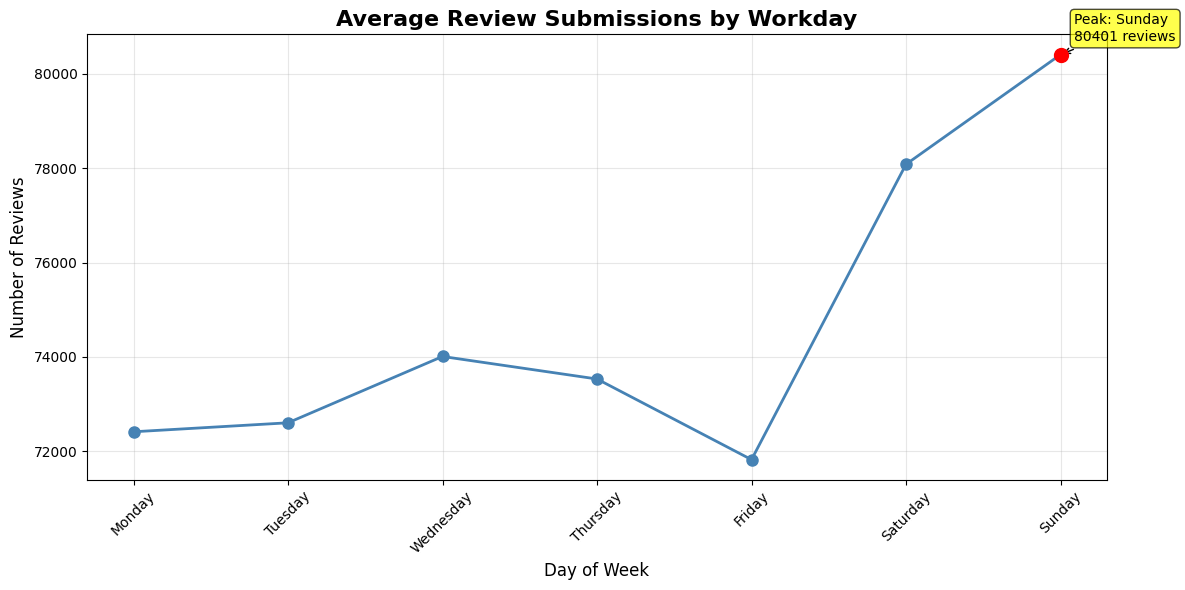


Peak workday for reviews: Sunday with 80401 submissions


In [ ]:
# Question 1.3.1: Join with meta-business and determine peak workday
print("=== Question 1.3.1: Workday Analysis ===")

# Join review data with meta business data
meta_df_pd = meta_df.toPandas()
full_df = df.merge(meta_df_pd, on='gmap_id', how='left')

print(f"Full dataset shape after joining: {full_df.shape}")
print(f"Columns after join: {list(full_df.columns)}")

# Create workday column (day of the week)
full_df['workday'] = full_df['newtime'].dt.day_name()

# Calculate review submissions by workday
workday_submissions = full_df.groupby('workday').size().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

print("\nReview submissions by workday:")
for day, count in workday_submissions.items():
    print(f"{day}: {count} reviews")

# Plot workday submissions as line chart
plt.figure(figsize=(12, 6))
plt.plot(workday_submissions.index, workday_submissions.values,
         marker='o', linewidth=2, markersize=8, color='steelblue')
plt.title('Average Review Submissions by Workday', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Highlight peak day
peak_day = workday_submissions.idxmax()
peak_value = workday_submissions.max()
plt.scatter(peak_day, peak_value, color='red', s=100, zorder=5)
plt.annotate(f'Peak: {peak_day}\n{peak_value} reviews',
            xy=(peak_day, peak_value), xytext=(10, 10),
            textcoords='offset points', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print(f"\nPeak workday for reviews: {peak_day} with {peak_value} submissions")

Peak day: Sunday with 76860 reviews

Top 10 businesses on Sunday:
                               name  avg_rating  review_count  \
4                      203 Kombucha         5.0             6   
13               3 Friends Dog Park         5.0             8   
36                 A Desert Passage         5.0             6   
71                         AK Joint         5.0             7   
153   Alaska Axe Co. - Axe Throwing         5.0            12   
186            Alaska Denali Winery         5.0             5   
192             Alaska Escape Rooms         5.0             9   
212    Alaska Horse Adventures, LLC         5.0             5   
233             Alaska Mini Storage         5.0             5   
243  Alaska Pablo's Bicycle Rentals         5.0             5   

                     category  
4                   Tea house  
13                   Dog park  
36              Jewelry store  
71             Cannabis store  
153               Sports club  
186                    Win

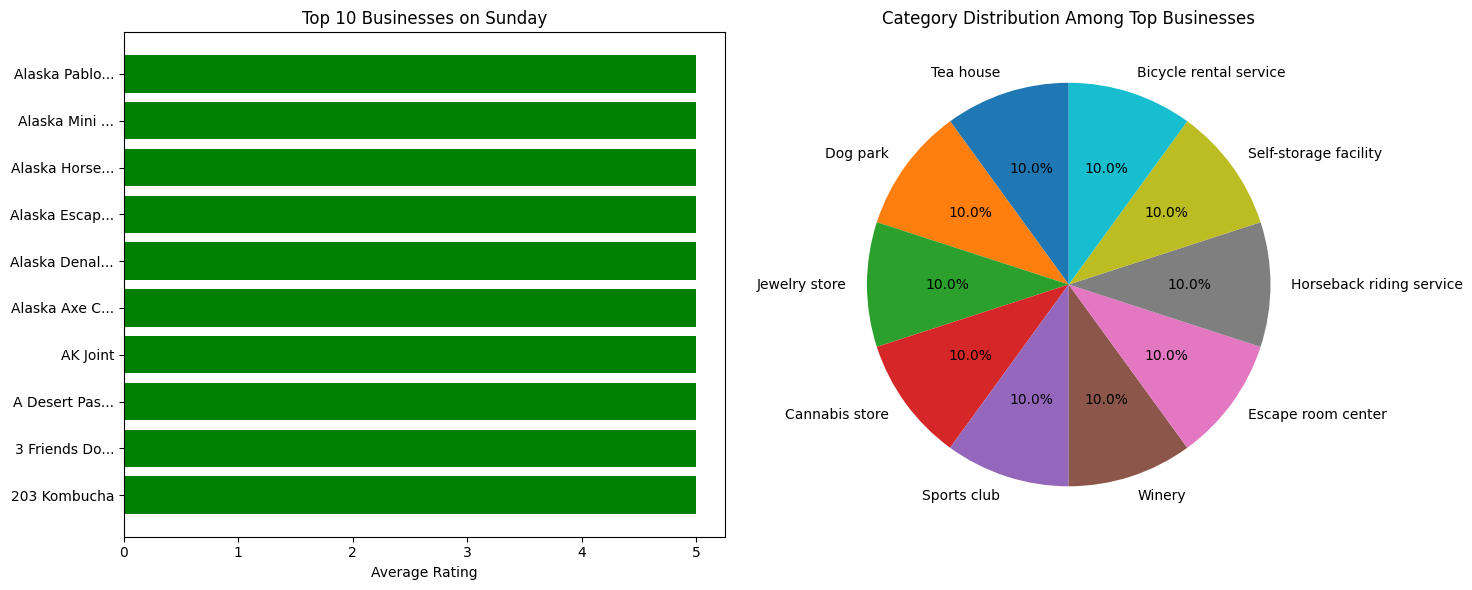

In [ ]:
# Convert Spark DataFrames to Pandas
reviews_pd = review_df_clean.select('user_id', 'gmap_id', 'time', 'rating', 'text').toPandas()
meta_pd = meta_df.select('gmap_id', 'name', 'category').toPandas()

# Clean and convert time to datetime
reviews_pd['time'] = pd.to_numeric(reviews_pd['time'], errors='coerce')
reviews_pd['datetime'] = pd.to_datetime(reviews_pd['time'], unit='ms', errors='coerce')
reviews_pd = reviews_pd.dropna(subset=['datetime'])
reviews_pd['day_of_week'] = reviews_pd['datetime'].dt.day_name()

# Merge reviews with metadata
full_pd = reviews_pd.merge(meta_pd, on='gmap_id', how='inner')

# Convert rating to numeric and drop invalids
full_pd['rating'] = pd.to_numeric(full_pd['rating'], errors='coerce')
full_pd = full_pd.dropna(subset=['rating'])

# Robust category flattening
def extract_primary_category(cat):
    if isinstance(cat, list) and len(cat) > 0:
        return cat[0]
    if isinstance(cat, str):
        try:
            parsed = ast.literal_eval(cat)
            if isinstance(parsed, list) and len(parsed) > 0:
                return parsed[0]
        except Exception:
            return cat
    return None

full_pd['category_flat'] = full_pd['category'].apply(extract_primary_category)

# Find peak day
peak_day = full_pd['day_of_week'].value_counts().idxmax()
peak_review_count = full_pd['day_of_week'].value_counts().max()
print(f"Peak day: {peak_day} with {peak_review_count} reviews")

# Filter for peak day
peak_data = full_pd[full_pd['day_of_week'] == peak_day]

# Group and aggregate
agg = peak_data.groupby('name').agg(
    avg_rating=('rating', 'mean'),
    review_count=('rating', 'count'),
    category=('category_flat', 'first')
).reset_index().round(2)

# Top 10 with at least 5 reviews
top10 = agg[agg['review_count'] >= 5].nlargest(10, 'avg_rating')

print(f"\nTop 10 businesses on {peak_day}:")
print(top10[['name', 'avg_rating', 'review_count', 'category']])

# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

names_short = [n if len(n) <= 15 else n[:12] + '...' for n in top10['name']]
ax1.barh(range(len(top10)), top10['avg_rating'], color='green')
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels(names_short)
ax1.set_xlabel('Average Rating')
ax1.set_title(f'Top 10 Businesses on {peak_day}')

cat_counts = top10['category'].value_counts()
ax2.pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Category Distribution Among Top Businesses')

plt.tight_layout()
plt.show()

=== Question 1.3.3: Additional Business and Category Insights ===


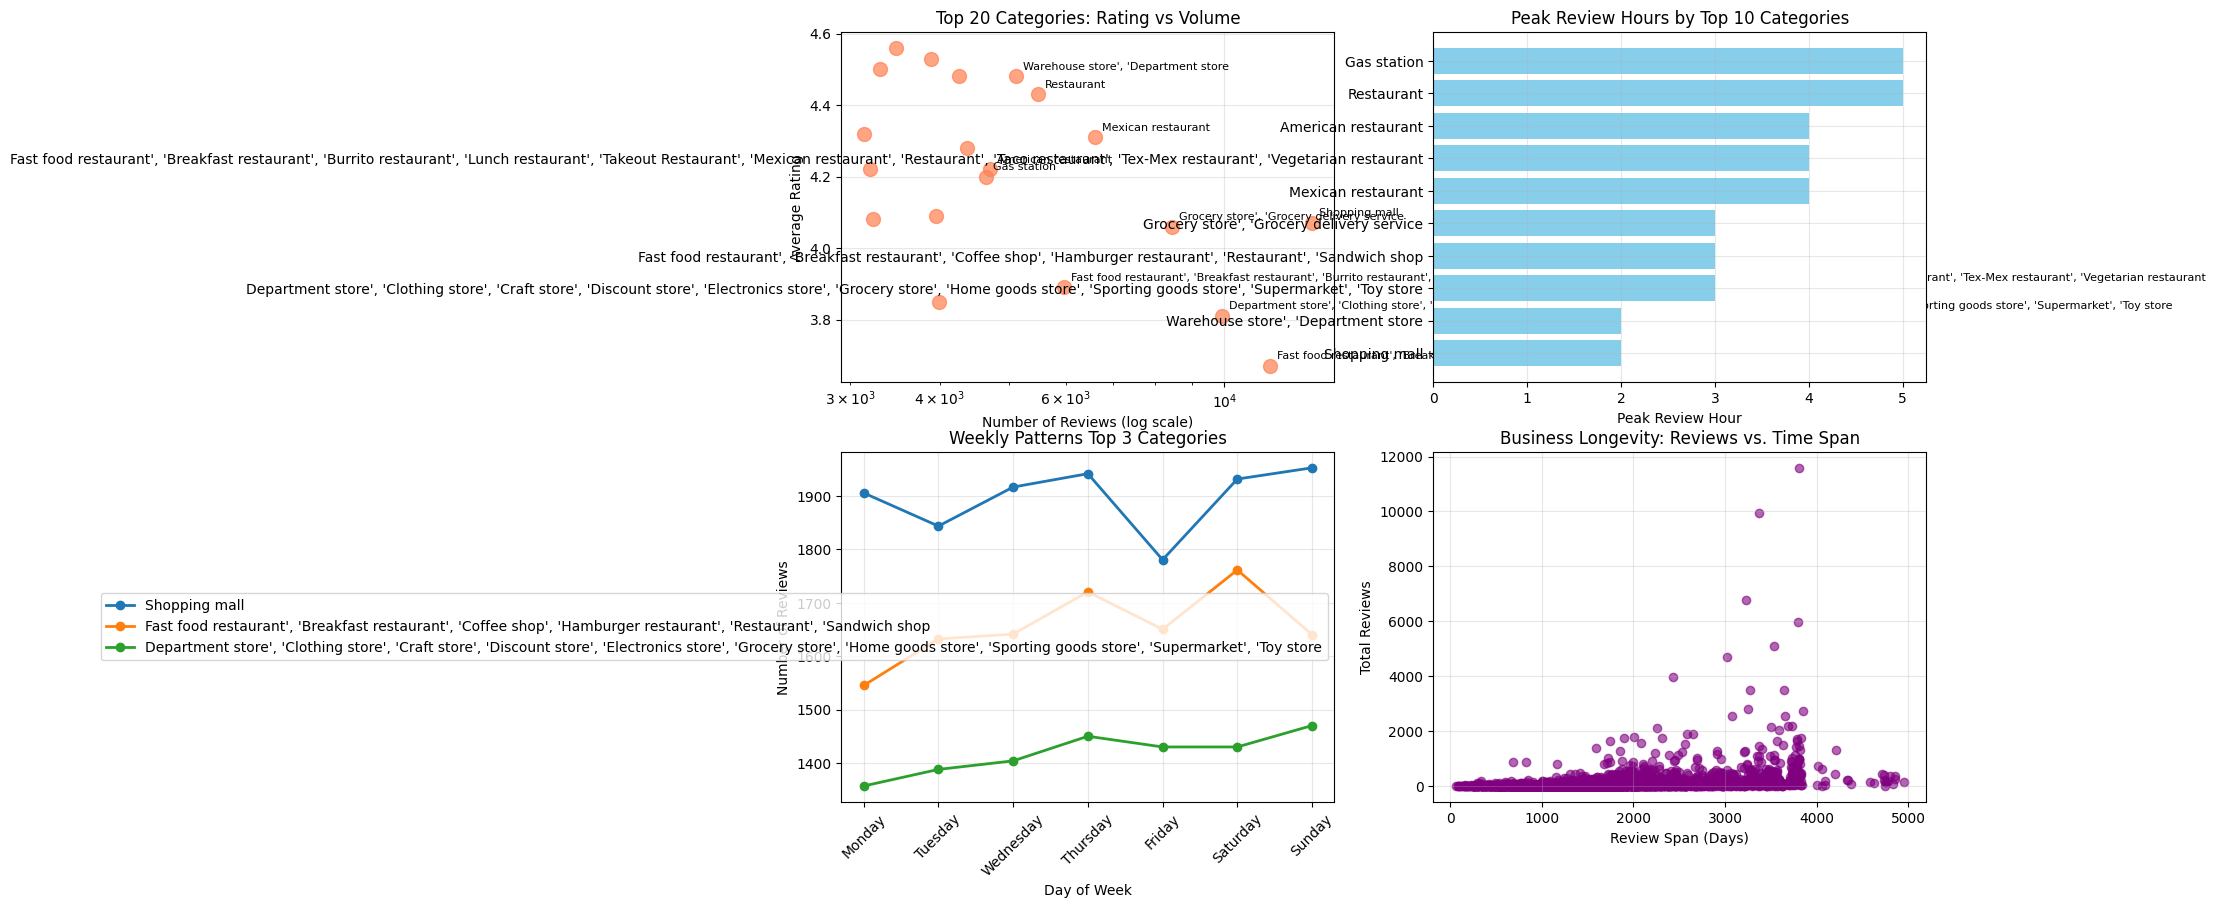


=== Key Insights ===
1. Most reviewed category: Shopping mall
2. Highest rated category (avg): Cannabis store (4.56 stars)
3. Most active businesses have review spans of 1585 days

4. Peak review hours by top 10 categories (descending order of review count):
   Shopping mall: 2:00
   Fast food restaurant', 'Breakfast restaurant', 'Coffee shop', 'Hamburger restaurant', 'Restaurant', 'Sandwich shop: 3:00
   Department store', 'Clothing store', 'Craft store', 'Discount store', 'Electronics store', 'Grocery store', 'Home goods store', 'Sporting goods store', 'Supermarket', 'Toy store: 3:00
   Grocery store', 'Grocery delivery service: 3:00
   Mexican restaurant: 4:00
   Fast food restaurant', 'Breakfast restaurant', 'Burrito restaurant', 'Lunch restaurant', 'Takeout Restaurant', 'Mexican restaurant', 'Restaurant', 'Taco restaurant', 'Tex-Mex restaurant', 'Vegetarian restaurant: 4:00
   Restaurant: 5:00
   Warehouse store', 'Department store: 2:00
   American restaurant: 4:00
   Gas statio

In [ ]:
# Question 1.3.3: Additional insights exploration
print("=== Question 1.3.3: Additional Business and Category Insights ===")

# --- Category cleaning ---
def clean_category(cat):
    if isinstance(cat, list) and len(cat) > 0:
        return str(cat[0]).strip()
    if isinstance(cat, str):
        try:
            parsed = ast.literal_literal_eval(cat)
            if isinstance(parsed, list) and len(parsed) > 0:
                return str(parsed[0]).strip()
        except:
            pass
        cat = re.sub(r"^[\[\]'\"\s]+|[\[\]'\"\s]+$", "", cat)
        return cat.strip()
    return None

full_pd['clean_category'] = full_pd['category'].apply(clean_category)

# Add time-based columns as needed
if 'review_time' not in full_pd.columns:
    full_pd['review_time'] = full_pd['datetime'].dt.hour
if 'workday' not in full_pd.columns:
    full_pd['workday'] = full_pd['datetime'].dt.day_name()
if 'newtime' not in full_pd.columns:
    full_pd['newtime'] = full_pd['datetime']

plt.figure(figsize=(14, 10))

# --- Plot 1: Top 20 categories, log scale for clarity ---
category_stats = full_pd.groupby('clean_category')['rating'].agg(['mean', 'count']).round(2)
category_stats = category_stats[category_stats['count'] >= 50]
category_stats_top = category_stats.sort_values('count', ascending=False).head(20)

plt.subplot(2, 2, 1)
plt.scatter(category_stats_top['count'], category_stats_top['mean'], s=100, color='coral', alpha=0.7)
top10_annotate = category_stats_top.sort_values('count', ascending=False).head(10)
for idx, row in top10_annotate.iterrows():
    plt.annotate(idx, (row['count'], row['mean']), xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.xscale('log')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Average Rating')
plt.title('Top 20 Categories: Rating vs Volume')
plt.grid(True, alpha=0.3)

# Step 2: Limit peak review hours to top 10 categories by review count
top_categories_for_peak_hours = full_pd['clean_category'].value_counts().head(10).index

category_peak_hours_filtered = {}
for category in top_categories_for_peak_hours:
    cat_data = full_pd[full_pd['clean_category'] == category]
    if not cat_data['review_time'].empty:
        peak_hour = cat_data['review_time'].mode().iloc[0]
        category_peak_hours_filtered[category] = peak_hour

# Plot 2: Horizontal bar chart for top 10 categories only
plt.subplot(2, 2, 2)
peak_df_filtered = pd.DataFrame(list(category_peak_hours_filtered.items()), columns=['Category', 'Peak_Hour'])
peak_df_filtered = peak_df_filtered.sort_values('Peak_Hour')

plt.barh(peak_df_filtered['Category'], peak_df_filtered['Peak_Hour'], color='skyblue')
plt.xlabel('Peak Review Hour')
plt.title('Peak Review Hours by Top 10 Categories')
plt.grid(True, alpha=0.3)

# --- Plot 3: Weekly review patterns, top 3 categories ---
WEEKDAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_cat = full_pd.groupby(['workday', 'clean_category']).size().unstack(fill_value=0)
weekday_cat = weekday_cat.reindex(WEEKDAYS)

top_3_cats = full_pd['clean_category'].value_counts().head(3).index
plt.subplot(2, 2, 3)
for cat in top_3_cats:
    if cat in weekday_cat.columns:
        plt.plot(weekday_cat.index, weekday_cat[cat], marker='o', label=cat, linewidth=2)
plt.xlabel('Day of Week')
plt.ylabel('Number of Reviews')
plt.title('Weekly Patterns Top 3 Categories')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# --- Plot 4: Business longevity ---
plt.subplot(2, 2, 4)
activity = full_pd.groupby('name')['newtime'].agg(['min', 'max', 'count'])
activity['span_days'] = (activity['max'] - activity['min']).dt.days
activity = activity[activity['count'] >= 10]

plt.scatter(activity['span_days'], activity['count'], alpha=0.6, color='purple')
plt.xlabel('Review Span (Days)')
plt.ylabel('Total Reviews')
plt.title('Business Longevity: Reviews vs. Time Span')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Key Insights ---
print("\n=== Key Insights ===")
most_reviewed_cat = full_pd['clean_category'].value_counts().idxmax()
print(f"1. Most reviewed category: {most_reviewed_cat}")
if not category_stats_top.empty:
    max_avg_cat = category_stats_top['mean'].idxmax()
    print(f"2. Highest rated category (avg): {max_avg_cat} ({category_stats_top['mean'].max():.2f} stars)")
else:
    print("2. Not enough data for highest rated category.")

if not activity.empty:
    median_span = activity['span_days'].median()
    print(f"3. Most active businesses have review spans of {median_span:.0f} days")
else:
    print("3. Insufficient business data with enough reviews.")

# Define ordered_cats here
ordered_cats = full_pd['clean_category'].value_counts().head(10).index.tolist()
category_peak_hours = category_peak_hours_filtered # Use the results from earlier calculation

print("\n4. Peak review hours by top 10 categories (descending order of review count):")
for cat in ordered_cats:
    print(f"   {cat}: {category_peak_hours.get(cat, 'N/A')}:00")

Question 1.4: Word Frequency Analysis and Word Clouds
---
Objective: Analyze review text content to identify common words and trends over time.

=== Question 1.4: Text Analysis and Word Clouds ===
Total reviews with text content: 277126

Top 30 Most Common Words in Reviews:
----------------------------------------
 1. service         (40,930 occurrences)
 2. staff           (25,647 occurrences)
 3. friendly        (24,101 occurrences)
 4. always          (21,448 occurrences)
 5. best            (19,877 occurrences)
 6. love            (18,458 occurrences)
 7. amazing         (11,357 occurrences)
 8. clean           (11,245 occurrences)
 9. awesome         (11,187 occurrences)
10. prices          (10,986 occurrences)
11. people          (10,720 occurrences)
12. store           (10,431 occurrences)
13. well            (9,790 occurrences)
14. will            (9,767 occurrences)
15. helpful         (9,490 occurrences)
16. excellent       (9,238 occurrences)
17. little          (8,994 occurrences)
18. selection       (8,580 occurrences)
19. fast            (8,406 occurrences)
20. delicious       (8,366 occurrences)
21. pizza        

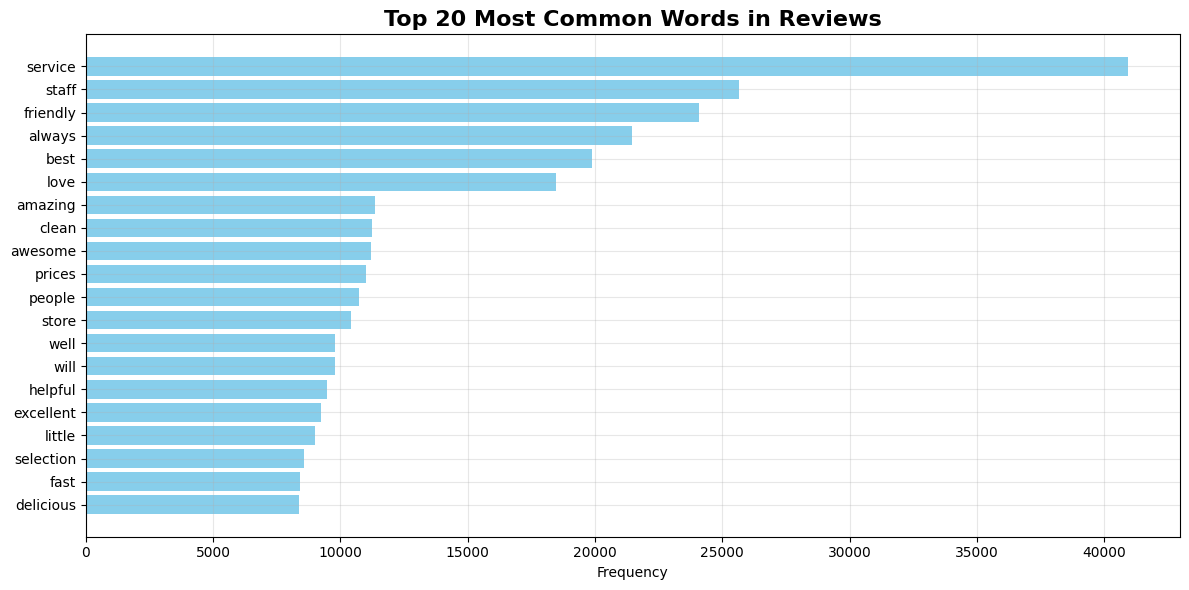

In [ ]:
# Question 1.4: Word frequency analysis and word clouds
print("=== Question 1.4: Text Analysis and Word Clouds ===")

# Prepare text data - filter out 'no review' entries for meaningful analysis, Use 'full_pd' for consistency
text_data = full_pd[full_pd['text'].notna() & (full_pd['text'] != 'no review')]['text']
print(f"Total reviews with text content: {len(text_data)}")

def clean_text(text):
    """Remove special characters and lowercase text"""
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    text = ' '.join(text.split())
    return text

# Clean all text
cleaned_texts = text_data.apply(clean_text)

# Combine and tokenize
all_text = ' '.join(cleaned_texts)
words = all_text.split()

# Define custom stopwords (can expand if required)
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'restaurant', 'food', 'place', 'good', 'great', 'nice',
    'really', 'would', 'could', 'also', 'one', 'two', 'get',
    'go', 'went', 'come', 'back', 'time', 'review', 'business'
])

# Filter out stopwords and short words
meaningful_words = [w for w in words if w not in custom_stopwords and len(w) > 2]

# Word frequency
word_freq = Counter(meaningful_words)
top_30_words = word_freq.most_common(30)

print("\nTop 30 Most Common Words in Reviews:")
print("-" * 40)
for i, (word, count) in enumerate(top_30_words, 1):
    print(f"{i:2d}. {word:<15} ({count:,} occurrences)")

# Visualize top 20 words
plt.figure(figsize=(12, 6))
words_list, counts_list = zip(*top_30_words[:20])
plt.barh(range(len(words_list)), counts_list, color='skyblue')
plt.yticks(range(len(words_list)), words_list)
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words in Reviews', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

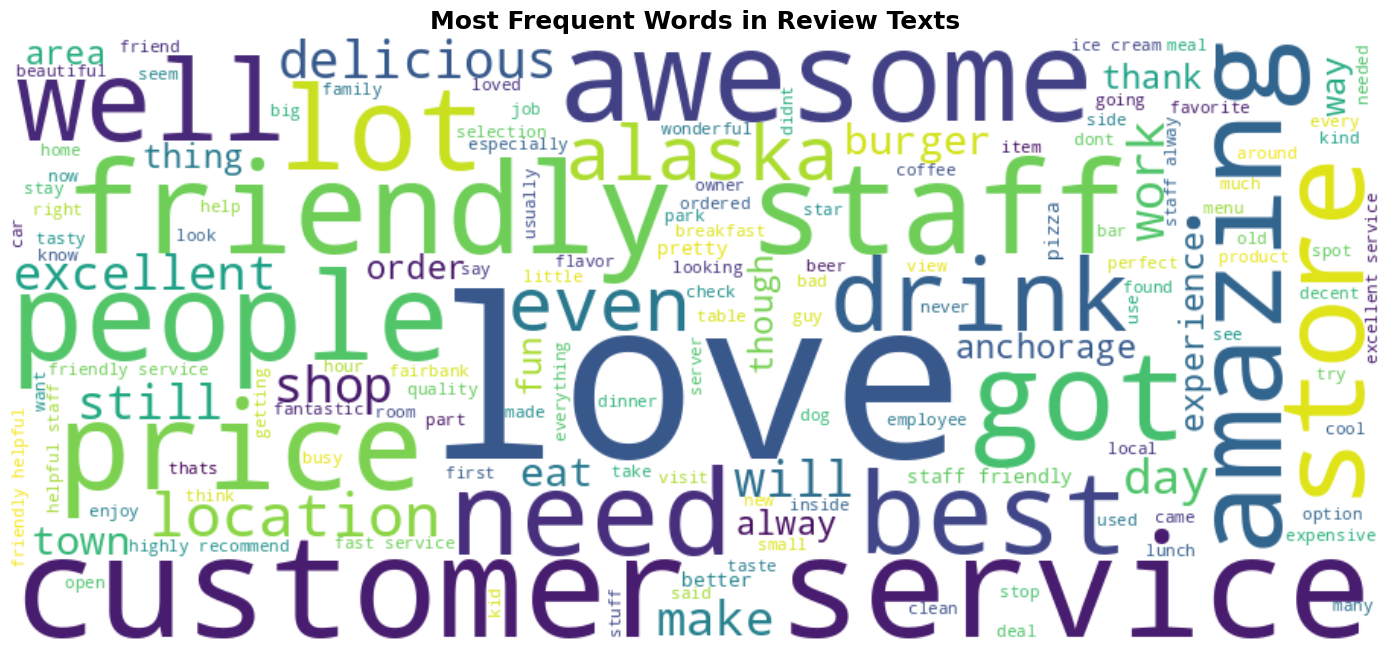

In [ ]:
# Combine meaningful words into a single string for wordcloud
wordcloud_text = ' '.join(meaningful_words)

# Create the word cloud object
wordcloud = WordCloud(
    width=900,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=150,
    colormap='viridis'
).generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Review Texts', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


=== Word Clouds by Year ===
Available years in data: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
Showing most recent 5 years: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]


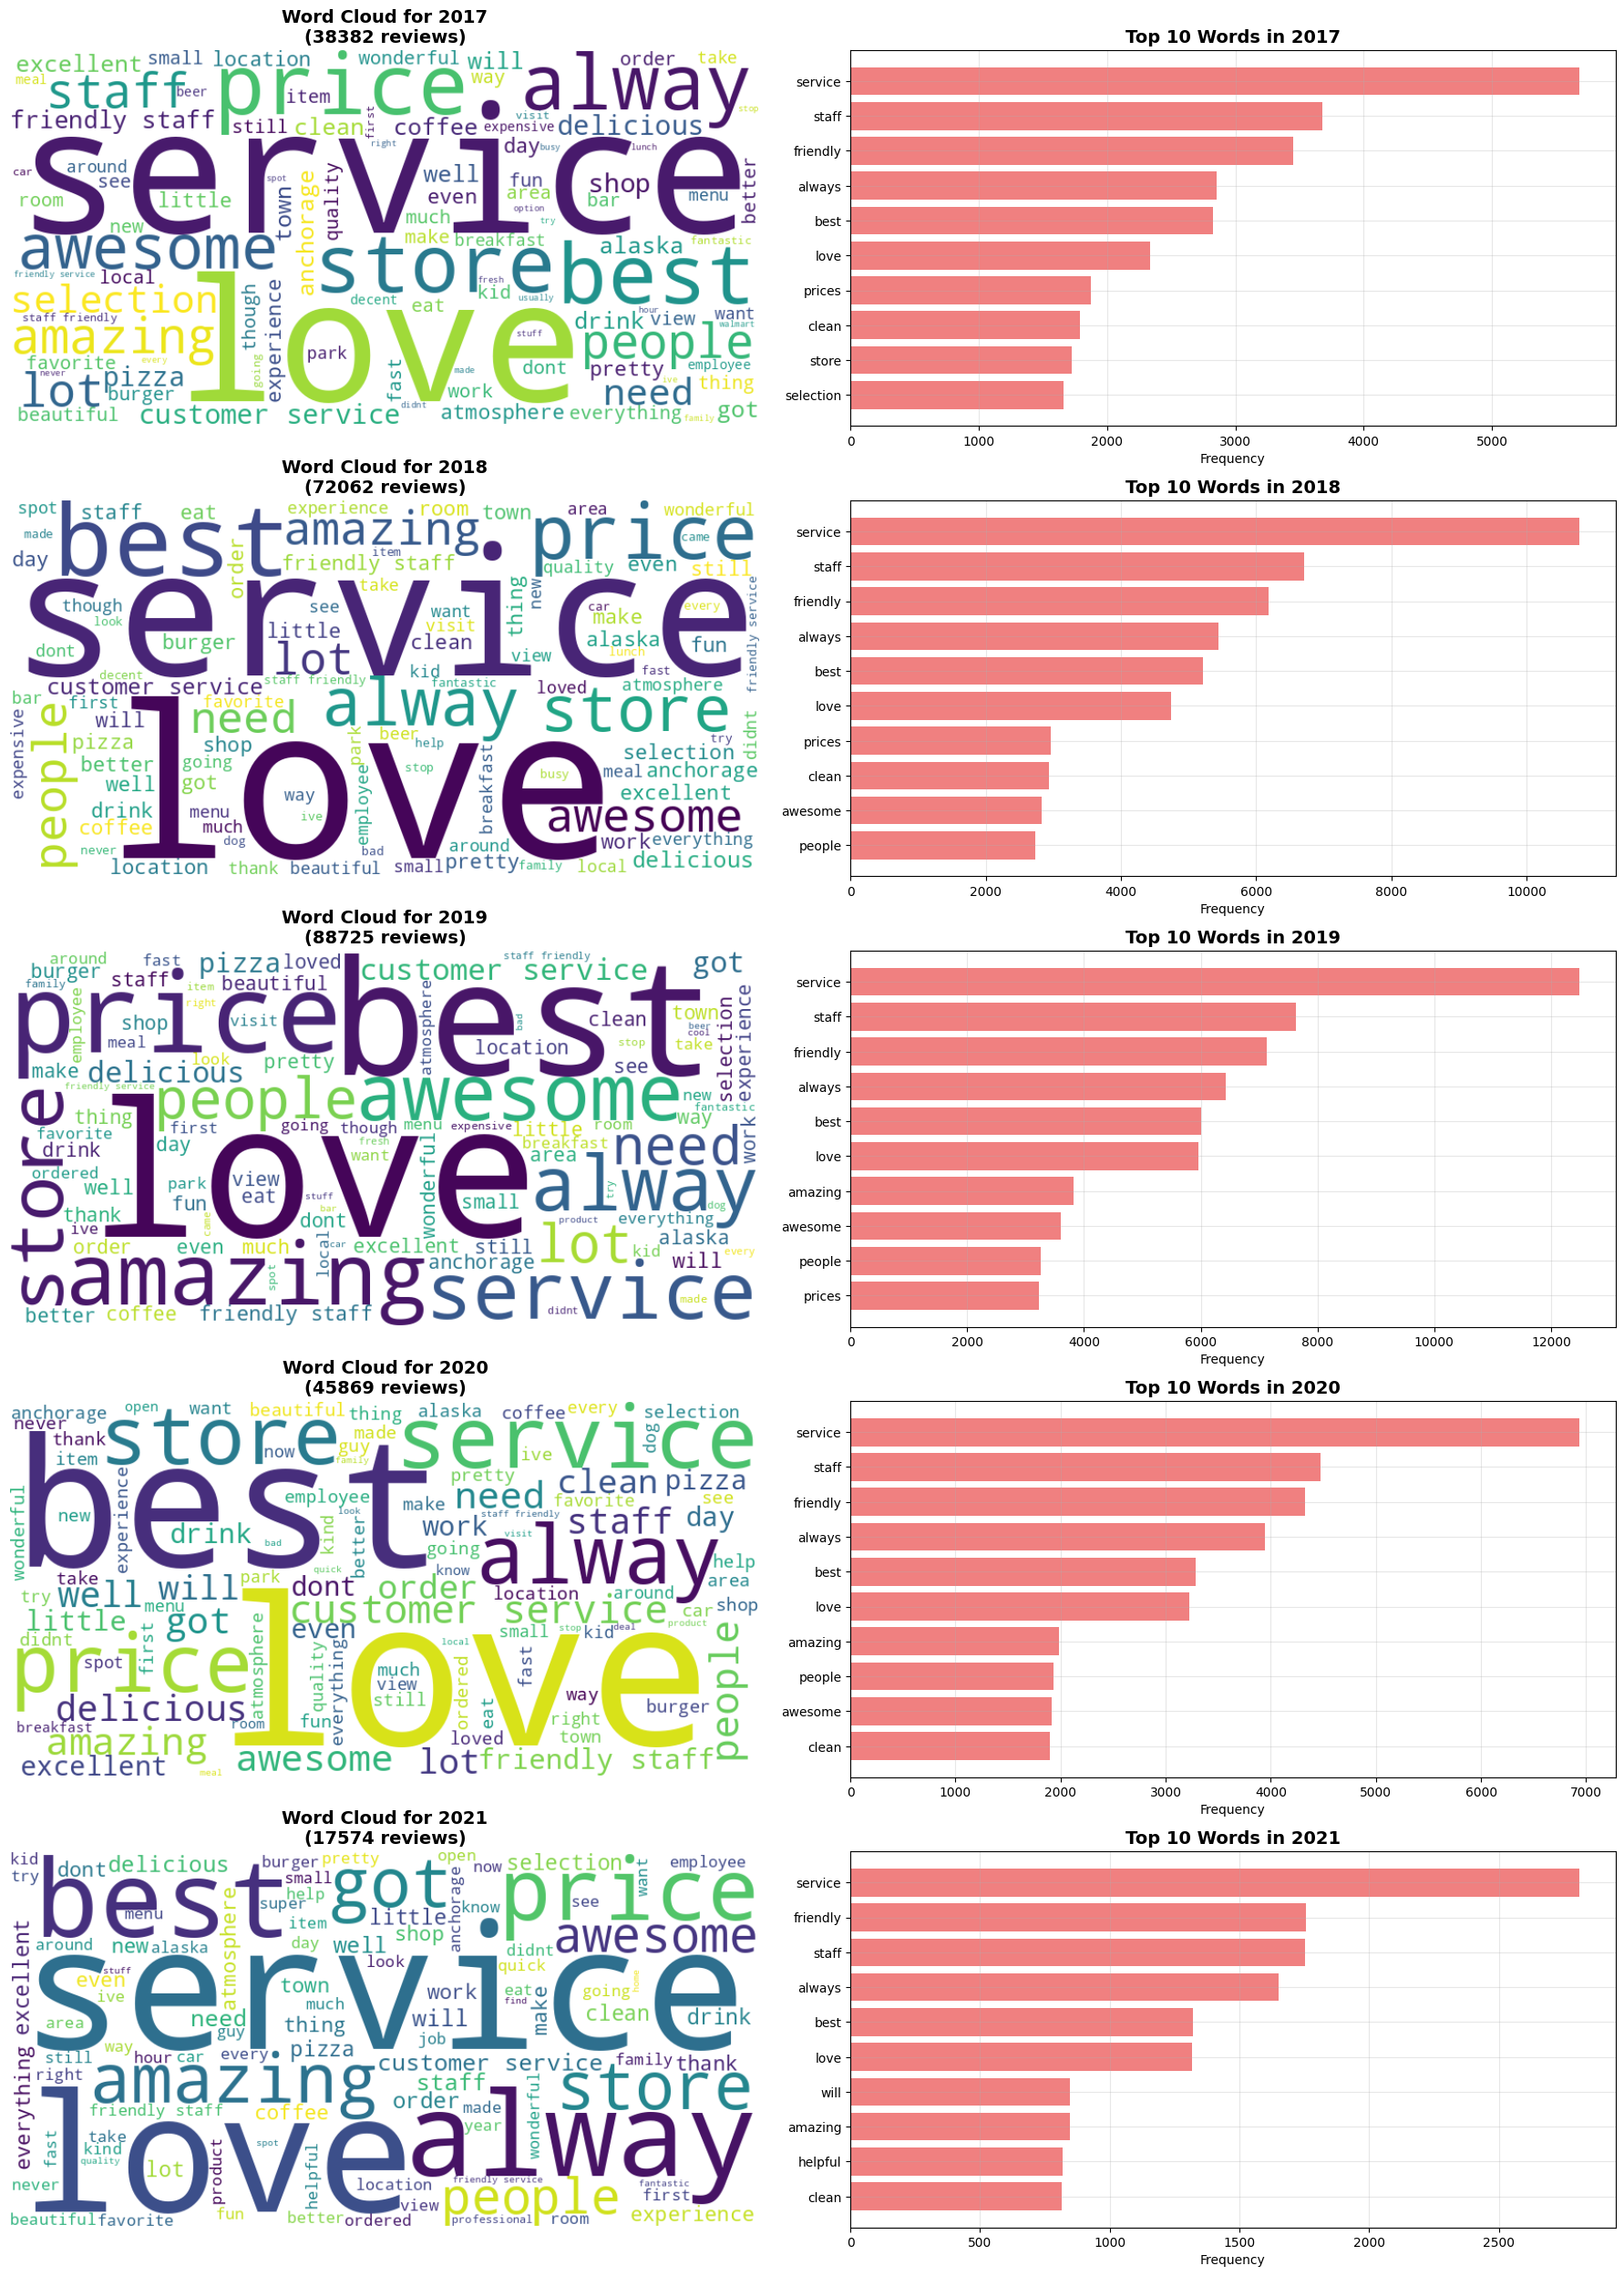


=== Yearly Word Trends Analysis (Recent 5 Years) ===

2017 - Top 5 words:
  • service: 5679 mentions
  • staff: 3677 mentions
  • friendly: 3450 mentions
  • always: 2855 mentions
  • best: 2825 mentions

2018 - Top 5 words:
  • service: 10776 mentions
  • staff: 6715 mentions
  • friendly: 6181 mentions
  • always: 5440 mentions
  • best: 5214 mentions

2019 - Top 5 words:
  • service: 12479 mentions
  • staff: 7627 mentions
  • friendly: 7135 mentions
  • always: 6423 mentions
  • best: 6006 mentions

2020 - Top 5 words:
  • service: 6933 mentions
  • staff: 4472 mentions
  • friendly: 4322 mentions
  • always: 3942 mentions
  • best: 3287 mentions

2021 - Top 5 words:
  • service: 2809 mentions
  • friendly: 1757 mentions
  • staff: 1754 mentions
  • always: 1649 mentions
  • best: 1320 mentions


In [ ]:
# Generate word clouds by year (recent 5 years)
print("\n=== Word Clouds by Year ===")

# Extract year from newtime and create year-based text groups
full_pd['review_year'] = full_pd['newtime'].dt.year
available_years = sorted(full_pd['review_year'].dropna().unique())
recent_years = available_years[-5:]  # Most recent 5 years

print(f"Available years in data: {available_years}")
print(f"Showing most recent 5 years: {recent_years}")

fig = plt.figure(figsize=(18, 5 * len(recent_years)))
yearly_insights = {}

for i, year in enumerate(recent_years):
    year_data = full_pd[full_pd['review_year'] == year]
    year_texts = year_data[year_data['text'].notna() & (year_data['text'] != 'no review')]['text']

    if len(year_texts) > 0:
        # Clean text
        cleaned_texts = year_texts.apply(clean_text)
        year_text_clean = ' '.join(cleaned_texts)

        # Filter meaningful words
        year_words = [word for word in year_text_clean.split()
                      if word not in custom_stopwords and len(word) > 2]
        year_word_freq = Counter(year_words)
        yearly_insights[year] = year_word_freq.most_common(10)
        year_text_for_cloud = ' '.join(year_words)

        # Word cloud
        plt.subplot(len(recent_years), 2, i * 2 + 1)
        if len(year_words) > 10:
            wordcloud = WordCloud(
                width=800, height=400,
                background_color='white',
                stopwords=custom_stopwords,
                max_words=100,
                colormap='viridis'
            ).generate(year_text_for_cloud)
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.title(f'Word Cloud for {int(year)}\n({len(year_texts)} reviews)',
                      fontsize=14, fontweight='bold')
            plt.axis('off')

        # Top words bar chart
        plt.subplot(len(recent_years), 2, i * 2 + 2)
        if year in yearly_insights:
            top_words, top_counts = zip(*yearly_insights[year][:10])
            plt.barh(range(len(top_words)), top_counts, color='lightcoral')
            plt.yticks(range(len(top_words)), top_words)
            plt.xlabel('Frequency')
            plt.title(f'Top 10 Words in {int(year)}',
                      fontsize=14, fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print recent 5 yearly insights
print("\n=== Yearly Word Trends Analysis (Recent 5 Years) ===")
for year in sorted(yearly_insights.keys()):
    print(f"\n{int(year)} - Top 5 words:")
    for word, count in yearly_insights[year][:5]:
        print(f"  • {word}: {count} mentions")


=== Additional Text Analysis Insights ===

Sentiment Analysis:
Positive sentiment words: 85,091 mentions
Negative sentiment words: 16,126 mentions
Positive/Negative ratio: 5.28

Average Review Length by Year:
2007: 116.0 characters
2008: 260.2 characters
2009: 404.7 characters
2010: 158.2 characters
2011: 174.7 characters
2012: 180.7 characters
2013: 190.1 characters
2014: 184.2 characters
2015: 147.6 characters
2016: 111.5 characters
2017: 93.5 characters
2018: 93.3 characters
2019: 90.3 characters
2020: 96.8 characters
2021: 103.2 characters


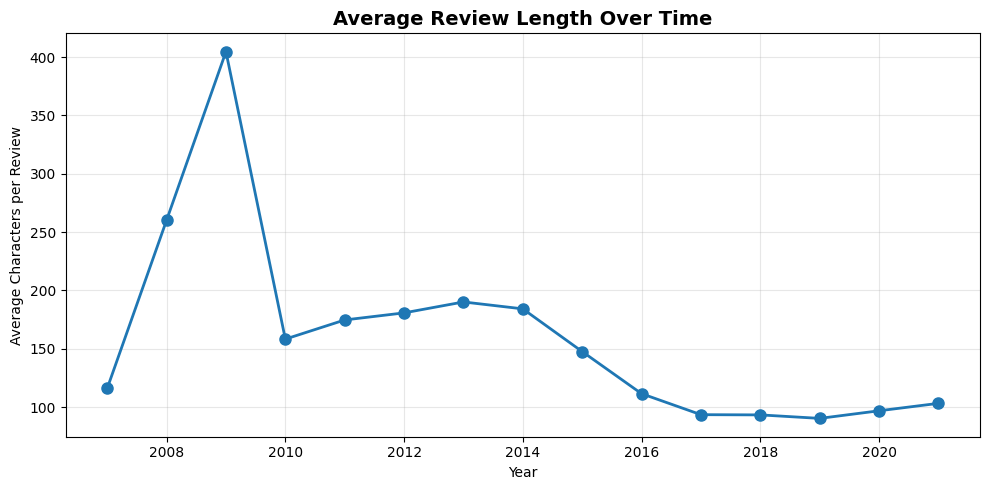


=== Key Text Insights ===
1. Most frequent meaningful word: 'service' (40,930 occurrences)
2. Vocabulary diversity: 55,577 unique words
3. Overall sentiment appears positive
4. Review length trend: decreasing over time


In [ ]:
# Additional text analysis insights
print("\n=== Additional Text Analysis Insights ===")

# Sentiment-related words definition
positive_words = ['excellent', 'amazing', 'perfect', 'wonderful', 'fantastic',
                  'outstanding', 'delicious', 'friendly', 'helpful', 'clean']
negative_words = ['terrible', 'awful', 'horrible', 'disappointing', 'dirty',
                  'rude', 'slow', 'expensive', 'bad', 'worst']

# Count sentiment words from previously computed word_freq
positive_count = sum(word_freq.get(word, 0) for word in positive_words)
negative_count = sum(word_freq.get(word, 0) for word in negative_words)

print(f"\nSentiment Analysis:")
print(f"Positive sentiment words: {positive_count:,} mentions")
print(f"Negative sentiment words: {negative_count:,} mentions")
print(f"Positive/Negative ratio: {positive_count / max(negative_count, 1):.2f}")

# Average review length by year (excluding 'no review')
full_pd['review_year'] = full_pd['newtime'].dt.year
yearly_length = full_pd.groupby('review_year')['text'].apply(
    lambda x: x[x != 'no review'].dropna().apply(len).mean()
).dropna()

print(f"\nAverage Review Length by Year:")
for year, length in yearly_length.items():
    print(f"{int(year)}: {length:.1f} characters")

# Plot average review length trend
plt.figure(figsize=(10, 5))
plt.plot(yearly_length.index, yearly_length.values, marker='o', linewidth=2, markersize=8)
plt.title('Average Review Length Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Characters per Review')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Additional key insights print
print("\n=== Key Text Insights ===")
print(f"1. Most frequent meaningful word: '{top_30_words[0][0]}' ({top_30_words[0][1]:,} occurrences)")
print(f"2. Vocabulary diversity: {len(set(meaningful_words)):,} unique words")
print(f"3. Overall sentiment appears {'positive' if positive_count > negative_count else 'negative'}")

if len(yearly_length) > 1:
    trend = "increasing" if yearly_length.iloc[-1] > yearly_length.iloc[0] else "decreasing"
    print(f"4. Review length trend: {trend} over time")
else:
    print("4. Insufficient data for review length trend analysis")

Question 1.5: Unique Reviewers and Temporal Patterns
---

Objective: Analyze unique reviewers per business/category and temporal submission patterns.

=== Question 1.5: Unique Reviewers and Temporal Patterns ===

1. Unique Reviewers Analysis

Unique Reviewers by Top 10 Categories:
• Shopping mall             7079 unique reviewers
• Department store', 'Clothing store', 'Craft store', 'Discount store', 'Electronics store', 'Grocery store', 'Home goods store', 'Sporting goods store', 'Supermarket', 'Toy store 6975 unique reviewers
• Fast food restaurant', 'Breakfast restaurant', 'Coffee shop', 'Hamburger restaurant', 'Restaurant', 'Sandwich shop 6855 unique reviewers
• Grocery store', 'Grocery delivery service 5696 unique reviewers
• Mexican restaurant        4908 unique reviewers
• Warehouse store', 'Department store 4352 unique reviewers
• Fast food restaurant', 'Breakfast restaurant', 'Burrito restaurant', 'Lunch restaurant', 'Takeout Restaurant', 'Mexican restaurant', 'Restaurant', 'Taco restaurant', 'Tex-Mex restaurant', 'Vegetarian restaurant 4319 unique reviewers
• Restaurant                4176 unique reviewers
• American restau

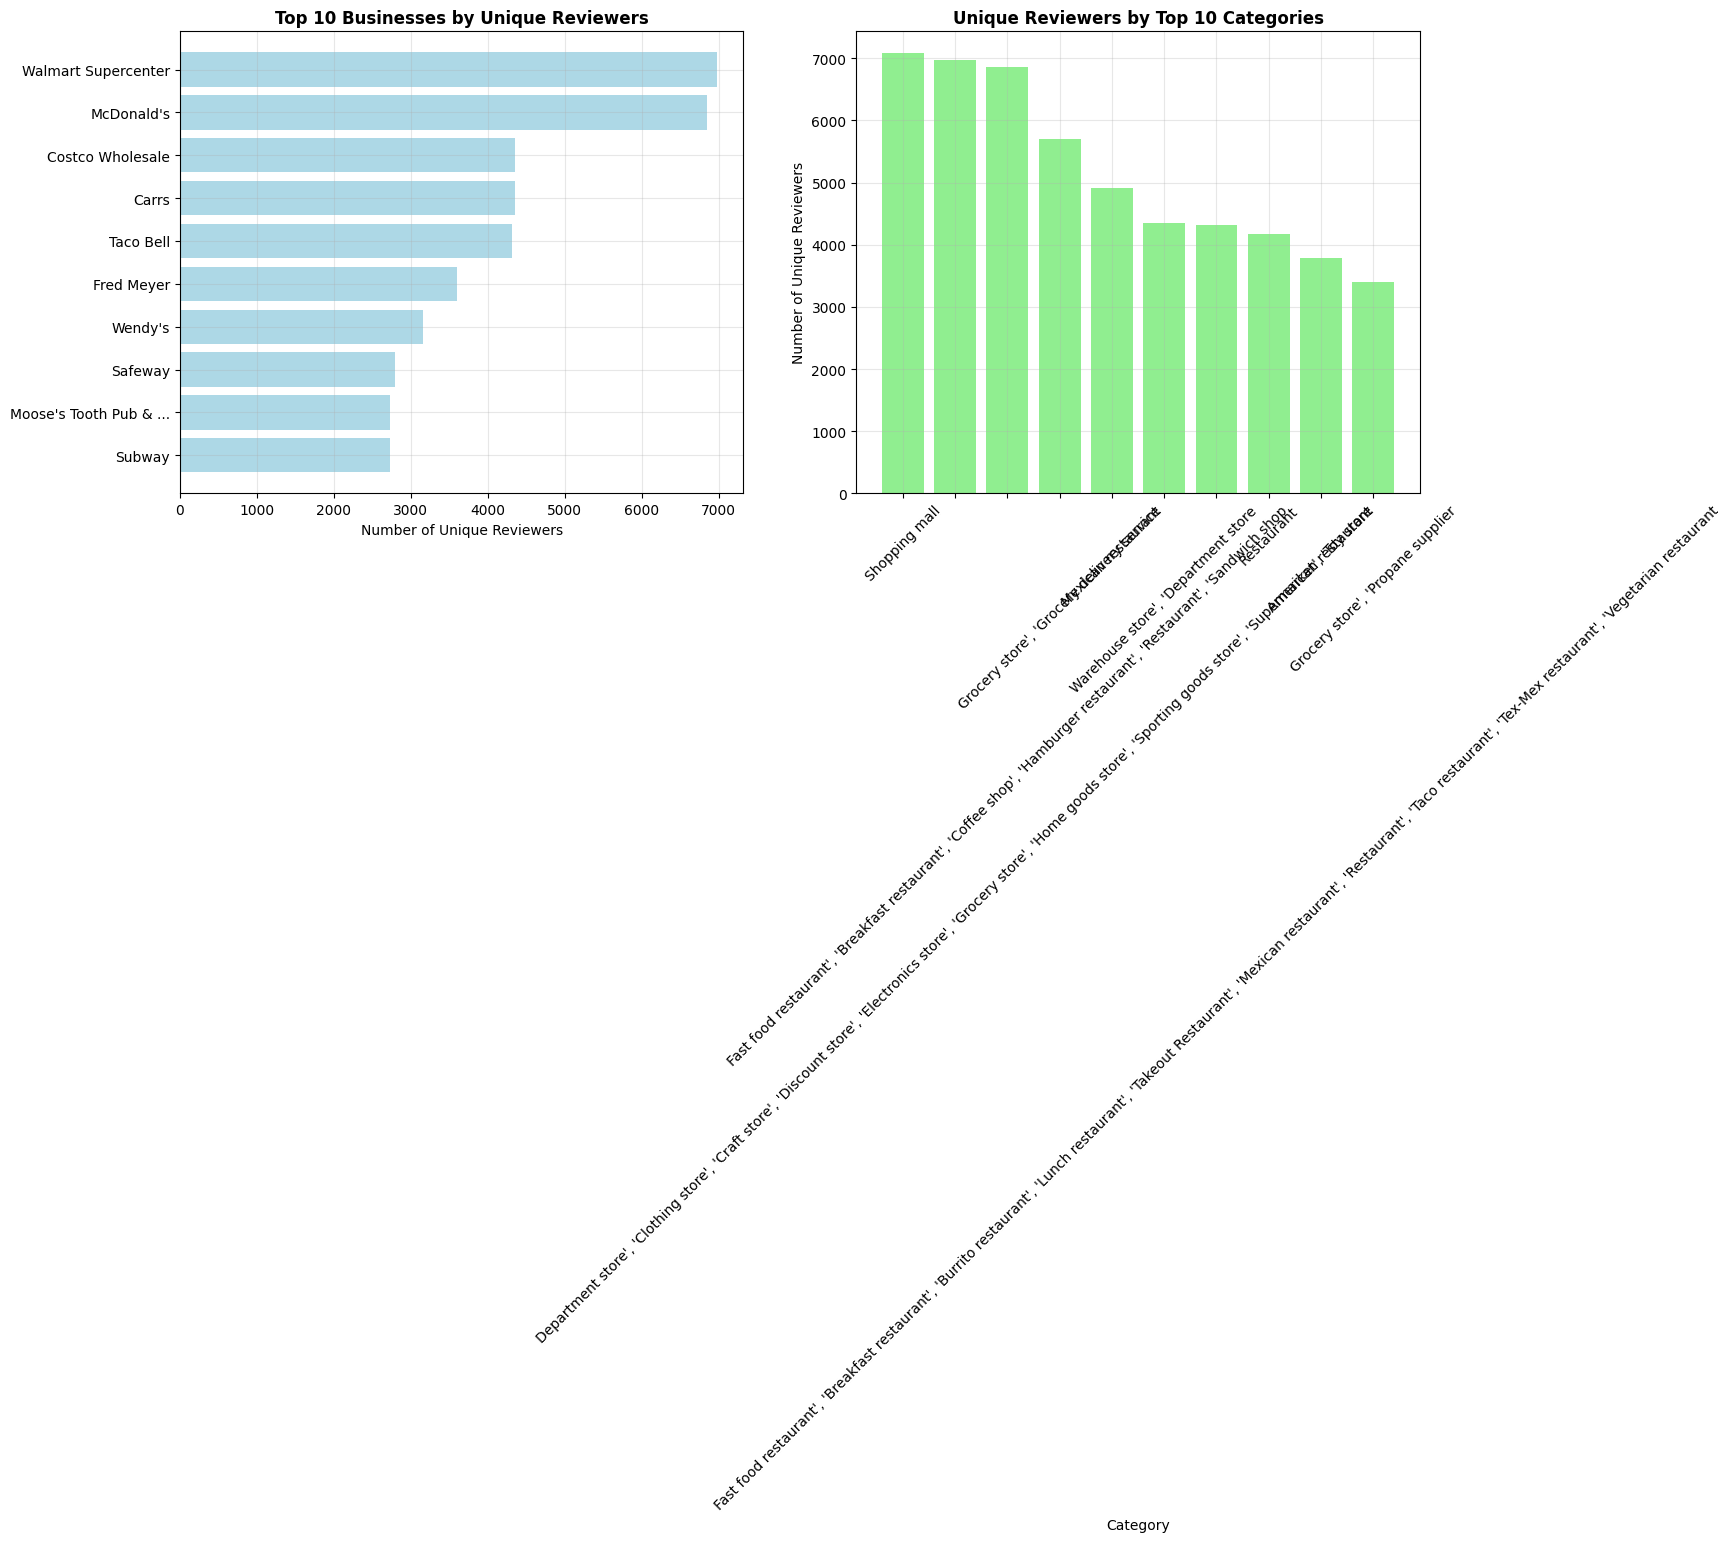


Summary Statistics:
• Business with most unique reviewers: Walmart Supercenter (6975)
• Category attracting most reviewers: Shopping mall (7079)
• Average unique reviewers per business: 91.3
• Total unique reviewers in dataset: 19974


In [ ]:
# Question 1.5: Unique reviewers and temporal patterns analysis
print("=== Question 1.5: Unique Reviewers and Temporal Patterns ===")

# 1.5.1: Unique reviewers per business
print("\n1. Unique Reviewers Analysis")

# Unique reviewers per business
unique_reviewers_business = full_pd.groupby('name')['user_id'].nunique().sort_values(ascending=False)

# Unique reviewers per category (using clean_category)
unique_reviewers_category = full_pd.groupby('clean_category')['user_id'].nunique().sort_values(ascending=False)

# Limit to top 10 categories
top_10_categories = unique_reviewers_category.head(10)

print("\nUnique Reviewers by Top 10 Categories:")
for category, count in top_10_categories.items():
    print(f"• {category:<25} {count:>4} unique reviewers")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot: Top 10 businesses by unique reviewers (unchanged)
top_10_businesses = unique_reviewers_business.head(10)
business_names_short = [name[:20] + '...' if len(name) > 20 else name for name in top_10_businesses.index]
ax1.barh(range(len(business_names_short)), top_10_businesses.values, color='lightblue')
ax1.set_yticks(range(len(business_names_short)))
ax1.set_yticklabels(business_names_short)
ax1.set_xlabel('Number of Unique Reviewers')
ax1.set_title('Top 10 Businesses by Unique Reviewers', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3)

# Plot: Unique reviewers by top 10 categories only
ax2.bar(top_10_categories.index, top_10_categories.values, color='lightgreen')
ax2.set_xlabel('Category')
ax2.set_ylabel('Number of Unique Reviewers')
ax2.set_title('Unique Reviewers by Top 10 Categories', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSummary Statistics:")
print(f"• Business with most unique reviewers: {unique_reviewers_business.index[0]} ({unique_reviewers_business.iloc[0]})")
print(f"• Category attracting most reviewers: {unique_reviewers_category.index[0]} ({unique_reviewers_category.iloc[0]})")
print(f"• Average unique reviewers per business: {unique_reviewers_business.mean():.1f}")
print(f"• Total unique reviewers in dataset: {full_pd['user_id'].nunique()}")



2. Temporal Patterns Analysis


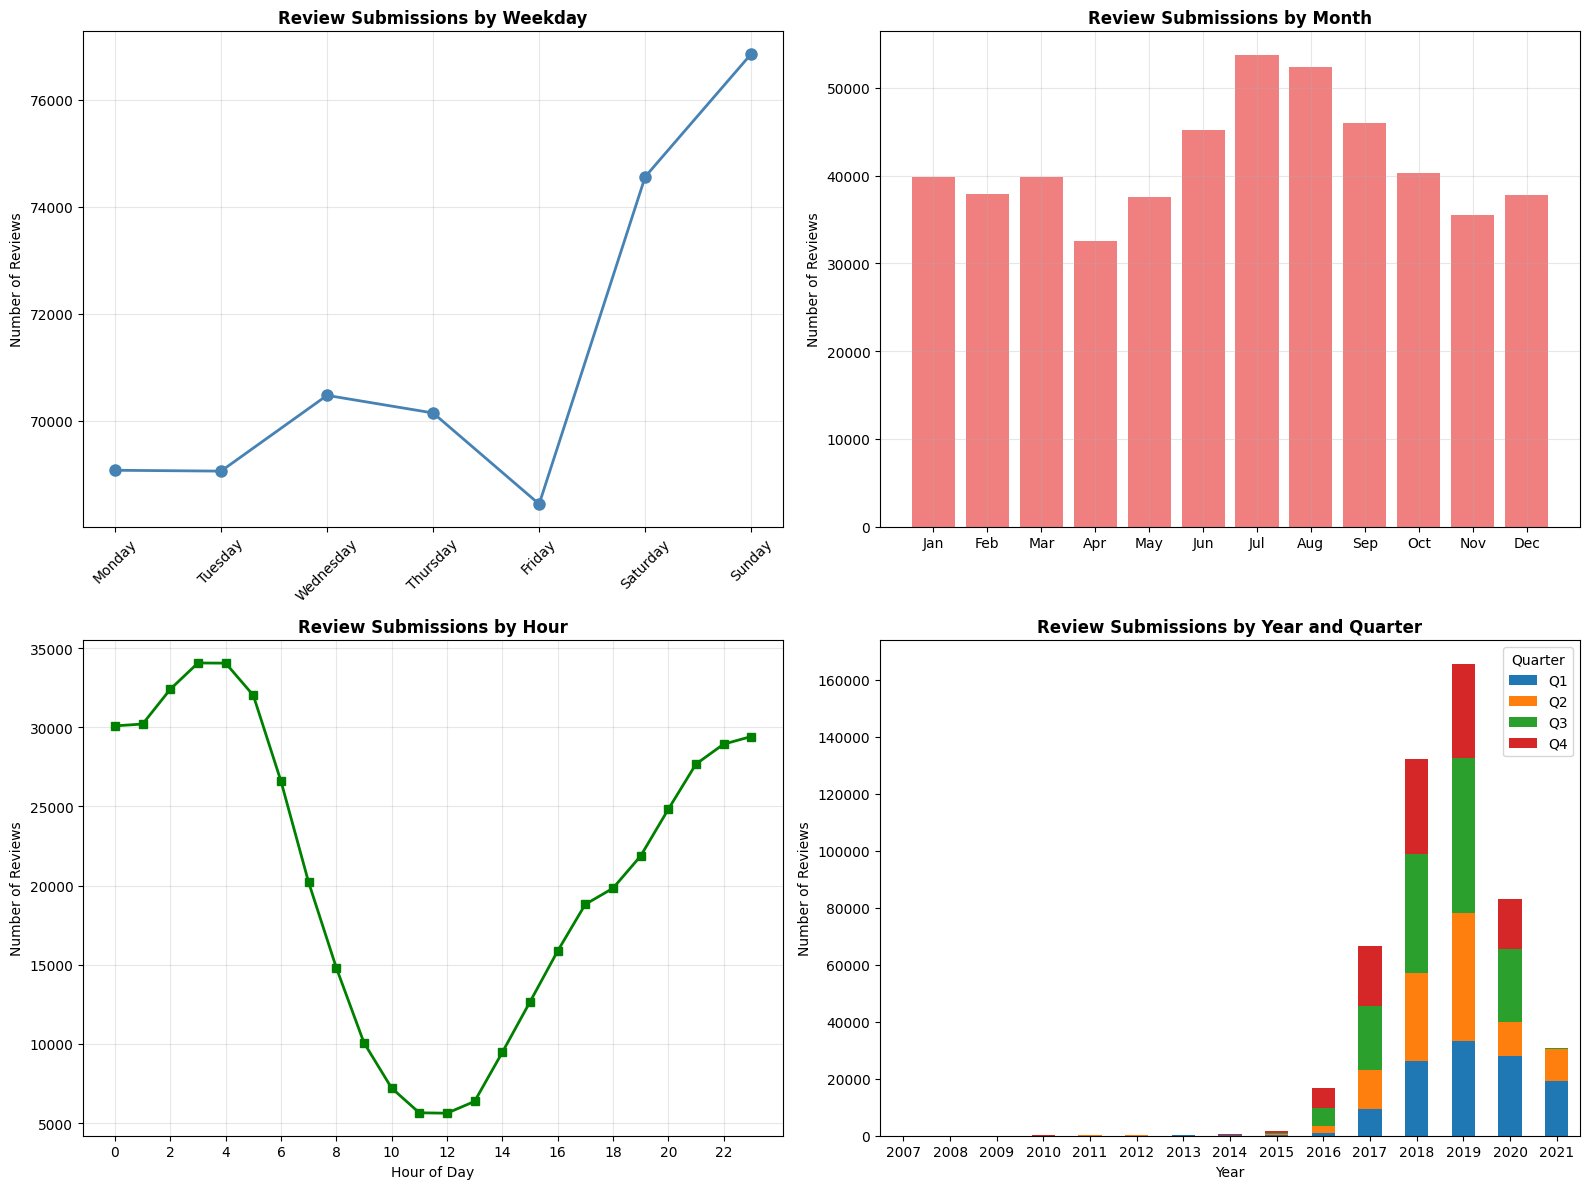


Temporal Pattern Insights:
• Peak weekday: Sunday (76860 reviews)
• Peak month: Jul (53751 reviews)
• Peak hour: 3:00 (34056 reviews)
• Weekend reviews: 151423 (30.4%)
• Weekday reviews: 347203 (69.6%)


In [ ]:
# 1.5.2: Temporal patterns analysis
print("\n\n2. Temporal Patterns Analysis")

# Create comprehensive temporal features
full_pd['month'] = full_pd['newtime'].dt.month
full_pd['hour'] = full_pd['newtime'].dt.hour
full_pd['day_of_month'] = full_pd['newtime'].dt.day
full_pd['quarter'] = full_pd['newtime'].dt.quarter

# Analyze temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Reviews by weekday
weekday_pattern = full_pd['workday'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
axes[0,0].plot(weekday_pattern.index, weekday_pattern.values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0,0].set_title('Review Submissions by Weekday', fontweight='bold')
axes[0,0].set_ylabel('Number of Reviews')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Reviews by month
month_pattern = full_pd['month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0,1].bar(range(1, 13), [month_pattern.get(i, 0) for i in range(1, 13)], color='lightcoral')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(month_names)
axes[0,1].set_title('Review Submissions by Month', fontweight='bold')
axes[0,1].set_ylabel('Number of Reviews')
axes[0,1].grid(True, alpha=0.3)

# 3. Reviews by hour
hour_pattern = full_pd['hour'].value_counts().sort_index()
axes[1,0].plot(hour_pattern.index, hour_pattern.values, marker='s', linewidth=2, color='green')
axes[1,0].set_title('Review Submissions by Hour', fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Number of Reviews')
axes[1,0].set_xticks(range(0, 24, 2))
axes[1,0].grid(True, alpha=0.3)

# 4. Reviews by year and quarter
year_quarter = full_pd.groupby(['review_year', 'quarter']).size().unstack(fill_value=0)
if len(year_quarter) > 1:
    year_quarter.plot(kind='bar', ax=axes[1,1], stacked=True)
    axes[1,1].set_title('Review Submissions by Year and Quarter', fontweight='bold')
    axes[1,1].set_xlabel('Year')
    axes[1,1].set_ylabel('Number of Reviews')
    axes[1,1].legend(title='Quarter', labels=['Q1', 'Q2', 'Q3', 'Q4'])
    axes[1,1].tick_params(axis='x', rotation=0)
else:
    quarter_pattern = full_pd['quarter'].value_counts().sort_index()
    axes[1,1].bar(['Q1', 'Q2', 'Q3', 'Q4'],
                  [quarter_pattern.get(i, 0) for i in range(1, 5)], color='orange')
    axes[1,1].set_title('Review Submissions by Quarter', fontweight='bold')
    axes[1,1].set_ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

# Print temporal insights
print("\nTemporal Pattern Insights:")
print(f"• Peak weekday: {weekday_pattern.idxmax()} ({weekday_pattern.max()} reviews)")
print(f"• Peak month: {month_names[month_pattern.idxmax()-1]} ({month_pattern.max()} reviews)")
print(f"• Peak hour: {hour_pattern.idxmax()}:00 ({hour_pattern.max()} reviews)")

# Weekend vs weekday analysis
weekend_days = ['Saturday', 'Sunday']
weekday_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekend_reviews = weekday_pattern[weekend_days].sum()
weekday_reviews = weekday_pattern[weekday_days].sum()

print(f"• Weekend reviews: {weekend_reviews} ({weekend_reviews/(weekend_reviews+weekday_reviews)*100:.1f}%)")
print(f"• Weekday reviews: {weekday_reviews} ({weekday_reviews/(weekend_reviews+weekday_reviews)*100:.1f}%)")


3. Advanced Reviewer Behavior Analysis
Reviewer Type Distribution:
• Regular User: 11580 reviewers (58.0%)
• Active User: 6338 reviewers (31.7%)
• Power User: 1951 reviewers (9.8%)
• Occasional User: 105 reviewers (0.5%)


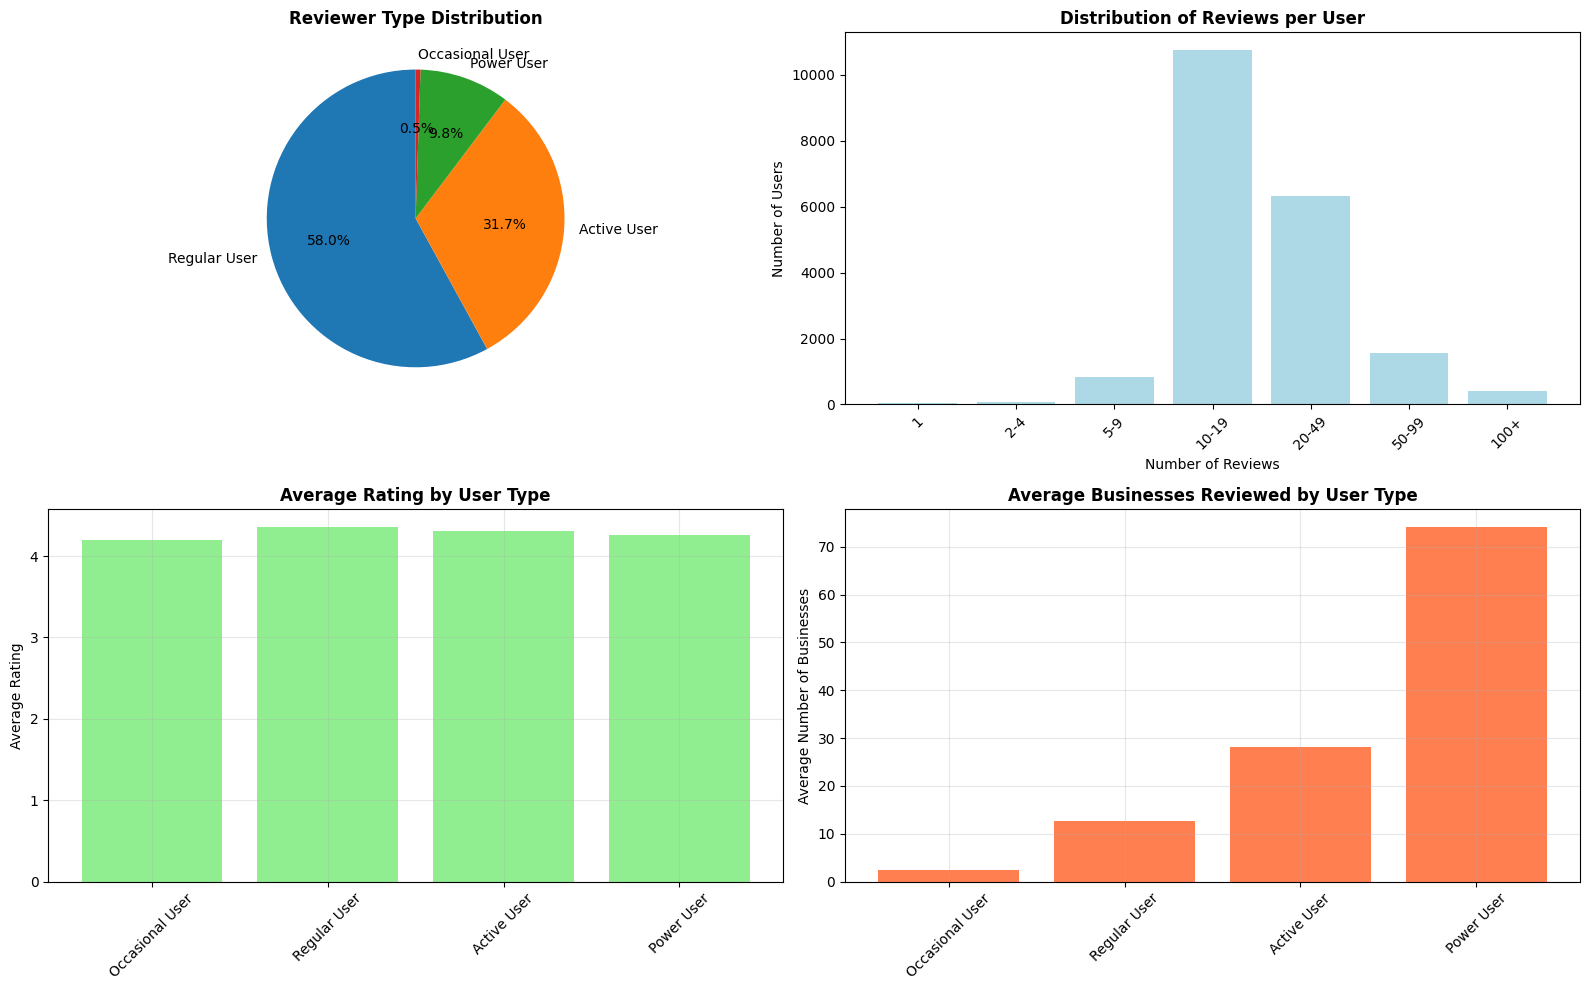


Key Reviewer Insights:
• Most prolific reviewer: 346 reviews
• Average reviews per user: 25.0
• Power users (1951 users) contribute 159536 reviews
• Most diverse reviewer visited 281 different businesses

Seasonal patterns show that Power Users are most active reviewers.


In [ ]:
# Advanced temporal and reviewer insights
print("\n3. Advanced Reviewer Behavior Analysis")

# Reviewer activity patterns
reviewer_stats = full_pd.groupby('user_id').agg({
    'rating': ['count', 'mean', 'std'],
    'newtime': ['min', 'max'],
    'clean_category': 'nunique',
    'name': 'nunique'
}).round(2)

# Flatten column names
reviewer_stats.columns = [
    'review_count', 'avg_rating', 'rating_std',
    'first_review', 'last_review', 'categories_reviewed', 'businesses_reviewed'
]

# Calculate review span
reviewer_stats['review_span_days'] = (reviewer_stats['last_review'] - reviewer_stats['first_review']).dt.days

# Categorize reviewers
def categorize_reviewer(row):
    if row['review_count'] >= 50:
        return 'Power User'
    elif row['review_count'] >= 20:
        return 'Active User'
    elif row['review_count'] >= 5:
        return 'Regular User'
    else:
        return 'Occasional User'

reviewer_stats['user_type'] = reviewer_stats.apply(categorize_reviewer, axis=1)

# Reviewer type distribution
user_type_dist = reviewer_stats['user_type'].value_counts()
print("Reviewer Type Distribution:")
for user_type, count in user_type_dist.items():
    percentage = count / len(reviewer_stats) * 100
    print(f"• {user_type}: {count} reviewers ({percentage:.1f}%)")

# Visualize reviewer patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. User type distribution
axes[0,0].pie(user_type_dist.values, labels=user_type_dist.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Reviewer Type Distribution', fontweight='bold')

# 2. Review count distribution
review_count_bins = [1, 2, 5, 10, 20, 50, 100, reviewer_stats['review_count'].max()+1]
review_count_hist, _ = np.histogram(reviewer_stats['review_count'], bins=review_count_bins)
bin_labels = ['1', '2-4', '5-9', '10-19', '20-49', '50-99', '100+']
axes[0,1].bar(bin_labels[:len(review_count_hist)], review_count_hist, color='lightblue')
axes[0,1].set_title('Distribution of Reviews per User', fontweight='bold')
axes[0,1].set_xlabel('Number of Reviews')
axes[0,1].set_ylabel('Number of Users')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Average rating by user type
avg_rating_by_type = reviewer_stats.groupby('user_type')['avg_rating'].mean().reindex([
    'Occasional User', 'Regular User', 'Active User', 'Power User'
])
axes[1,0].bar(avg_rating_by_type.index, avg_rating_by_type.values, color='lightgreen')
axes[1,0].set_title('Average Rating by User Type', fontweight='bold')
axes[1,0].set_ylabel('Average Rating')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 4. Business diversity by user type
avg_businesses_by_type = reviewer_stats.groupby('user_type')['businesses_reviewed'].mean().reindex([
    'Occasional User', 'Regular User', 'Active User', 'Power User'
])
axes[1,1].bar(avg_businesses_by_type.index, avg_businesses_by_type.values, color='coral')
axes[1,1].set_title('Average Businesses Reviewed by User Type', fontweight='bold')
axes[1,1].set_ylabel('Average Number of Businesses')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key insights
print(f"\nKey Reviewer Insights:")
print(f"• Most prolific reviewer: {reviewer_stats['review_count'].max()} reviews")
print(f"• Average reviews per user: {reviewer_stats['review_count'].mean():.1f}")
print(f"• Power users ({user_type_dist['Power User']} users) contribute {full_pd[full_pd['user_id'].isin(reviewer_stats[reviewer_stats['user_type']=='Power User'].index)].shape[0]} reviews")
print(f"• Most diverse reviewer visited {reviewer_stats['businesses_reviewed'].max()} different businesses")

# Seasonal patterns by user type
seasonal_by_type = full_pd.merge(reviewer_stats[['user_type']].reset_index(), on='user_id')
seasonal_pattern = seasonal_by_type.groupby(['user_type', 'month']).size().unstack(fill_value=0)

print(f"\nSeasonal patterns show that {'Power Users' if seasonal_pattern.loc['Power User'].sum() > seasonal_pattern.loc['Occasional User'].sum() else 'Occasional Users'} are most active reviewers.")

# Question 1.6: Recommendation System Implementation

In [ ]:
# Question 1.6: Recommendation System Strategy and Implementation
print("=== Question 1.6: Business Recommendation System ===" )

# 1.6.1: Strategy Documentation
recommendation_strategy = """
RECOMMENDATION SYSTEM STRATEGY:

1. APPROACH: Collaborative Filtering using K-Nearest Neighbors
   - Create user-business rating matrix
   - Use cosine similarity to find similar users
   - Recommend businesses liked by similar users

2. METHODOLOGY:
   - Data Preparation: Create pivot table (users × businesses)
   - Similarity Calculation: Cosine distance between user vectors
   - Recommendation Generation: Weighted average of neighbor ratings

3. ADVANTAGES:
   - Interpretable results
   - Works well with sparse data
   - No need for content features

4. LIMITATIONS:
   - Cold start problem for new users/businesses
   - Computational complexity for large datasets
   - Popularity bias
"""

print(recommendation_strategy)

=== Question 1.6: Business Recommendation System ===

RECOMMENDATION SYSTEM STRATEGY:

1. APPROACH: Collaborative Filtering using K-Nearest Neighbors
   - Create user-business rating matrix
   - Use cosine similarity to find similar users
   - Recommend businesses liked by similar users

2. METHODOLOGY:
   - Data Preparation: Create pivot table (users × businesses)
   - Similarity Calculation: Cosine distance between user vectors
   - Recommendation Generation: Weighted average of neighbor ratings

3. ADVANTAGES:
   - Interpretable results
   - Works well with sparse data
   - No need for content features

4. LIMITATIONS:
   - Cold start problem for new users/businesses
   - Computational complexity for large datasets
   - Popularity bias




=== Building Recommendation System ===
Filtered data: 498366 reviews, 19869 users, 5151 businesses
Utility matrix shape: (19869, 5151)

=== Testing Recommendation System ===

Generating recommendations for user: 1.0188830200557922e+20

User's rating history (top 10):
                            name  rating                                                                                                                                                                    clean_category
                           Carrs       5                                                                                                                                         Grocery store', 'Grocery delivery service
                      Alaska Zoo       5                                                                                                                                                         Zoo', 'Tourist attraction
             Super Suds Car Wash       5                                  

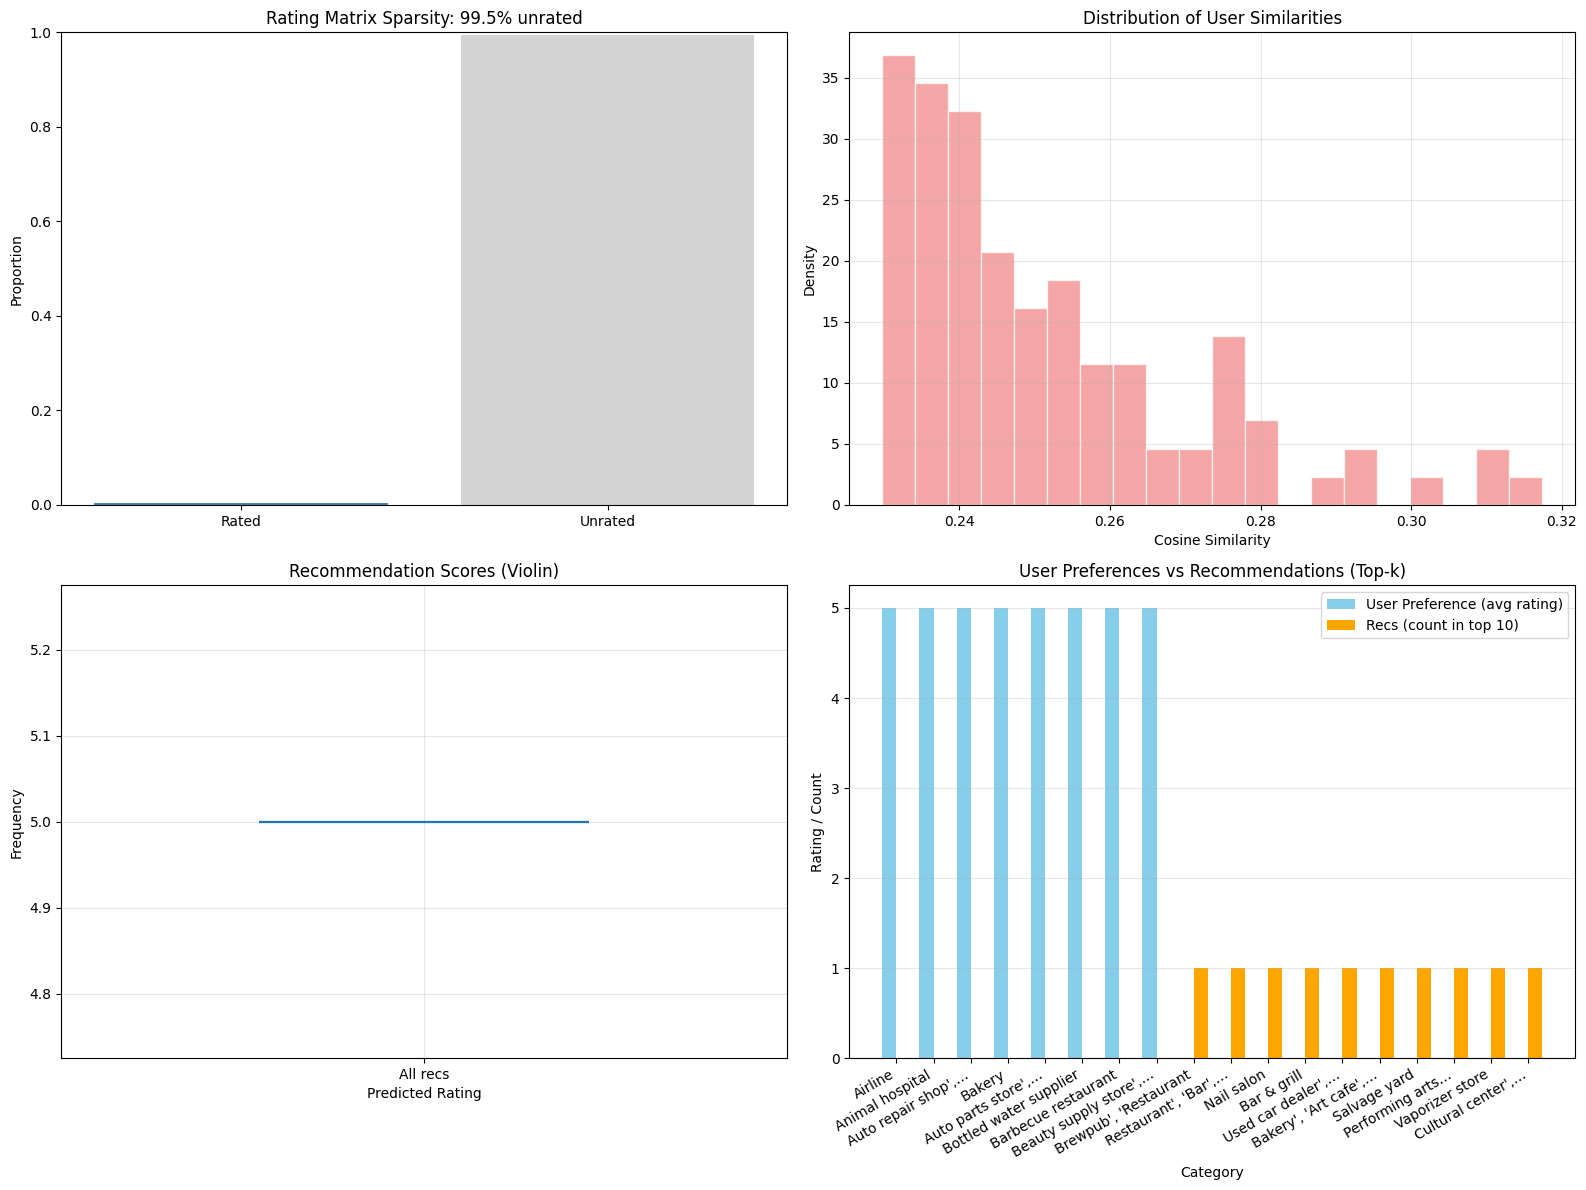


=== Recommendation System Analysis ===
1. Matrix Sparsity: 99.5% (typical for recommendation systems)
2. Average Similarity: 0.251
3. Recommendation Range: 5.00 - 5.00
4. Category Alignment: 0.0% recommendations match user preferences


In [ ]:
# 1.6.2: Implementation
# Create user-business rating matrix
print("\n=== Building Recommendation System ===")

# Filter for users and businesses with minimum activity
min_user_reviews = 5
min_business_reviews = 5

active_users = full_pd.groupby('user_id').size()
active_users = active_users[active_users >= min_user_reviews].index

active_businesses = full_pd.groupby('name').size()
active_businesses = active_businesses[active_businesses >= min_business_reviews].index

# Filter dataset
filtered_df = full_pd[
    (full_pd['user_id'].isin(active_users)) &
    (full_pd['name'].isin(active_businesses))
]

print(f"Filtered data: {len(filtered_df)} reviews, {filtered_df['user_id'].nunique()} users, {filtered_df['name'].nunique()} businesses")

# Create utility matrix
utility_matrix = filtered_df.pivot_table(
    index='user_id',
    columns='name',
    values='rating',
    fill_value=0
)

print(f"Utility matrix shape: {utility_matrix.shape}")

# Convert to sparse matrix for efficiency
sparse_matrix = csr_matrix(utility_matrix.values)

# Train KNN model
model_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=10
)
model_knn.fit(sparse_matrix)

def get_recommendations(user_id, n_recommendations=5):
    """
    Get business recommendations for a specific user

    Args:
        user_id: Target user ID
        n_recommendations: Number of recommendations to return

    Returns:
        List of recommended business names with predicted ratings
    """
    if user_id not in utility_matrix.index:
        return "User not found in training data"

    # Get user index
    user_idx = utility_matrix.index.get_loc(user_id)

    # Find similar users
    distances, indices = model_knn.kneighbors(
        utility_matrix.iloc[user_idx].values.reshape(1, -1),
        n_neighbors=6  # +1 because it includes the user itself
    )

    # Remove the user itself
    similar_users_idx = indices.flatten()[1:]
    similarities = 1 - distances.flatten()[1:]  # Convert distance to similarity

    # Get user's rated businesses
    user_ratings = utility_matrix.iloc[user_idx]
    rated_businesses = user_ratings[user_ratings > 0].index

    # Calculate weighted recommendations
    recommendations = {}

    for business in utility_matrix.columns:
        if business not in rated_businesses:  # Don't recommend already rated businesses
            # Get ratings from similar users for this business
            similar_user_ratings = utility_matrix.iloc[similar_users_idx][business]

            # Only consider users who rated this business
            valid_ratings = similar_user_ratings[similar_user_ratings > 0]

            if len(valid_ratings) > 0:
                # Get corresponding similarities for users who rated this business
                valid_similarities = similarities[similar_user_ratings > 0]

                # Calculate weighted average rating
                if valid_similarities.sum() > 0:
                    predicted_rating = np.average(valid_ratings, weights=valid_similarities)
                    recommendations[business] = predicted_rating

    # Sort and return top recommendations
    sorted_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    return sorted_recommendations[:n_recommendations]

# Test the recommendation system
print("\n=== Testing Recommendation System ===")

# Get a sample user with sufficient reviews
sample_users = filtered_df['user_id'].value_counts().head(3).index
test_user = sample_users[0]

print(f"\nGenerating recommendations for user: {test_user}")

# Show user's rating history
user_history = filtered_df[filtered_df['user_id'] == test_user][['name', 'rating', 'clean_category']].sort_values('rating', ascending=False)
print(f"\nUser's rating history (top 10):")
print(user_history.head(10).to_string(index=False))

# Generate recommendations
recommendations = get_recommendations(test_user, n_recommendations=10)

print(f"\nTop 10 Recommendations for {test_user}:")
print("-" * 50)
for i, (business, predicted_rating) in enumerate(recommendations, 1):
    # Get business category
    business_category = filtered_df[filtered_df['name'] == business]['clean_category'].iloc[0]
    print(f"{i:2d}. {business[:40]:<42} {predicted_rating:.2f} ⭐ ({business_category})")

# Evaluate recommendation quality
def evaluate_recommendations(user_id, n_test=5):
    """
    Simple evaluation by checking if recommended businesses
    are from categories the user typically rates highly
    """
    user_data = filtered_df[filtered_df['user_id'] == user_id]
    preferred_categories = user_data.groupby('clean_category')['rating'].mean().sort_values(ascending=False)

    recommendations = get_recommendations(user_id, n_recommendations=n_test)

    category_matches = 0
    for business, rating in recommendations:
        business_category = filtered_df[filtered_df['name'] == business]['clean_category'].iloc[0]
        if business_category in preferred_categories.head(3).index:
            category_matches += 1

    return category_matches / len(recommendations) if recommendations else 0

# Test evaluation
match_rate = evaluate_recommendations(test_user)
print(f"\nRecommendation Quality: {match_rate:.1%} match user's preferred categories")

# Visualization of recommendation system performance
plt.figure(figsize=(16, 12))

# Plot 1: User-Business Rating Matrix Sparsity
plt.subplot(2, 2, 1)
sparsity = (utility_matrix == 0).sum().sum() / (utility_matrix.shape[0] * utility_matrix.shape[1])
plt.bar(['Rated', 'Unrated'], [1-sparsity, sparsity], color=['steelblue', 'lightgray'])
plt.title(f'Rating Matrix Sparsity: {sparsity:.1%} unrated')
plt.ylabel('Proportion')
plt.ylim(0, 1)

# Plot 2: Distribution of user similarities (with KDE-like overlay via bins)
sample_user_idx = utility_matrix.index.get_loc(test_user)
distances, _ = model_knn.kneighbors(utility_matrix.iloc[sample_user_idx].values.reshape(1, -1), n_neighbors=100)
similarities = 1 - distances.flatten()

plt.subplot(2, 2, 2)
plt.hist(similarities[1:], bins=20, color='lightcoral', alpha=0.7, density=True, edgecolor='white')
plt.title('Distribution of User Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)

# Plot 3: Recommendation scores distribution (violin if low variance)
plt.subplot(2, 2, 3)
rec_scores = [score for _, score in recommendations]
if len(set(round(s, 2) for s in rec_scores)) <= 3:
    plt.violinplot(rec_scores, showmeans=True, showextrema=True)
    plt.title('Recommendation Scores (Violin)')
    plt.xticks([1], ['All recs'])
else:
    plt.hist(rec_scores, bins=min(10, len(set(rec_scores))), color='lightgreen', alpha=0.7, edgecolor='white')
    plt.title('Distribution of Recommendation Scores')
plt.xlabel('Predicted Rating')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Plot 4: Category preference vs recommendations (compact, top-k)
plt.subplot(2, 2, 4)
user_prefs_series = filtered_df[filtered_df['user_id'] == test_user].groupby('clean_category')['rating'].mean().sort_values(ascending=False)

# Choose top-k preferred categories
k = 8
topk_prefs = user_prefs_series.head(k)

# Count categories among top M recommendations
M = 10
rec_categories = [filtered_df[filtered_df['name'] == business]['clean_category'].iloc[0] for business, _ in recommendations[:M]]
rec_counts_series = pd.Series(rec_categories).value_counts()

# Union of categories to display: top-k prefs and those present in recs
cats_to_show = list(dict.fromkeys(list(topk_prefs.index) + list(rec_counts_series.index)))  # preserves order
# Truncate category labels for readability
labels = [textwrap.shorten(str(c), width=22, placeholder='…') for c in cats_to_show]

user_vals = [topk_prefs.get(c, 0) for c in cats_to_show]
rec_vals = [rec_counts_series.get(c, 0) for c in cats_to_show]

x = np.arange(len(cats_to_show))
width = 0.38
plt.bar(x - width/2, user_vals, width, label='User Preference (avg rating)', color='skyblue')
plt.bar(x + width/2, rec_vals, width, label='Recs (count in top 10)', color='orange')
plt.xlabel('Category')
plt.ylabel('Rating / Count')
plt.title('User Preferences vs Recommendations (Top-k)')
plt.xticks(x, labels, rotation=30, ha='right')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Recommendation System Analysis ===")
print(f"1. Matrix Sparsity: {sparsity:.1%} (typical for recommendation systems)")
print(f"2. Average Similarity: {similarities[1:].mean():.3f}")
print(f"3. Recommendation Range: {min(rec_scores):.2f} - {max(rec_scores):.2f}")
print(f"4. Category Alignment: {match_rate:.1%} recommendations match user preferences")

# Question 1.7: Rating Analysis by Category and Low Rating Investigation

=== Question 1.7: Rating Analysis by Category ===

1. Rating Distribution by Business Category
Category Rating Statistics (Min 30 reviews):
                                                    count  mean   std  median
clean_category                                                               
Dentist', 'Cosmetic dentist', 'Dental clinic', ...     32  5.00  0.00     5.0
Medical diagnostic imaging center', 'Mammograph...     42  5.00  0.00     5.0
Tour agency                                            31  4.97  0.18     5.0
National park', 'Nature preserve', 'Park               34  4.97  0.17     5.0
Sightseeing tour agency                                30  4.93  0.25     5.0
...                                                   ...   ...   ...     ...
Mobile home park', 'Real estate                        61  2.95  1.37     3.0
Apartment complex', 'Apartment rental agency           32  2.81  1.53     3.0
Post office', 'Logistics service', 'Money order...    207  2.78  1.76     3.0
Ta

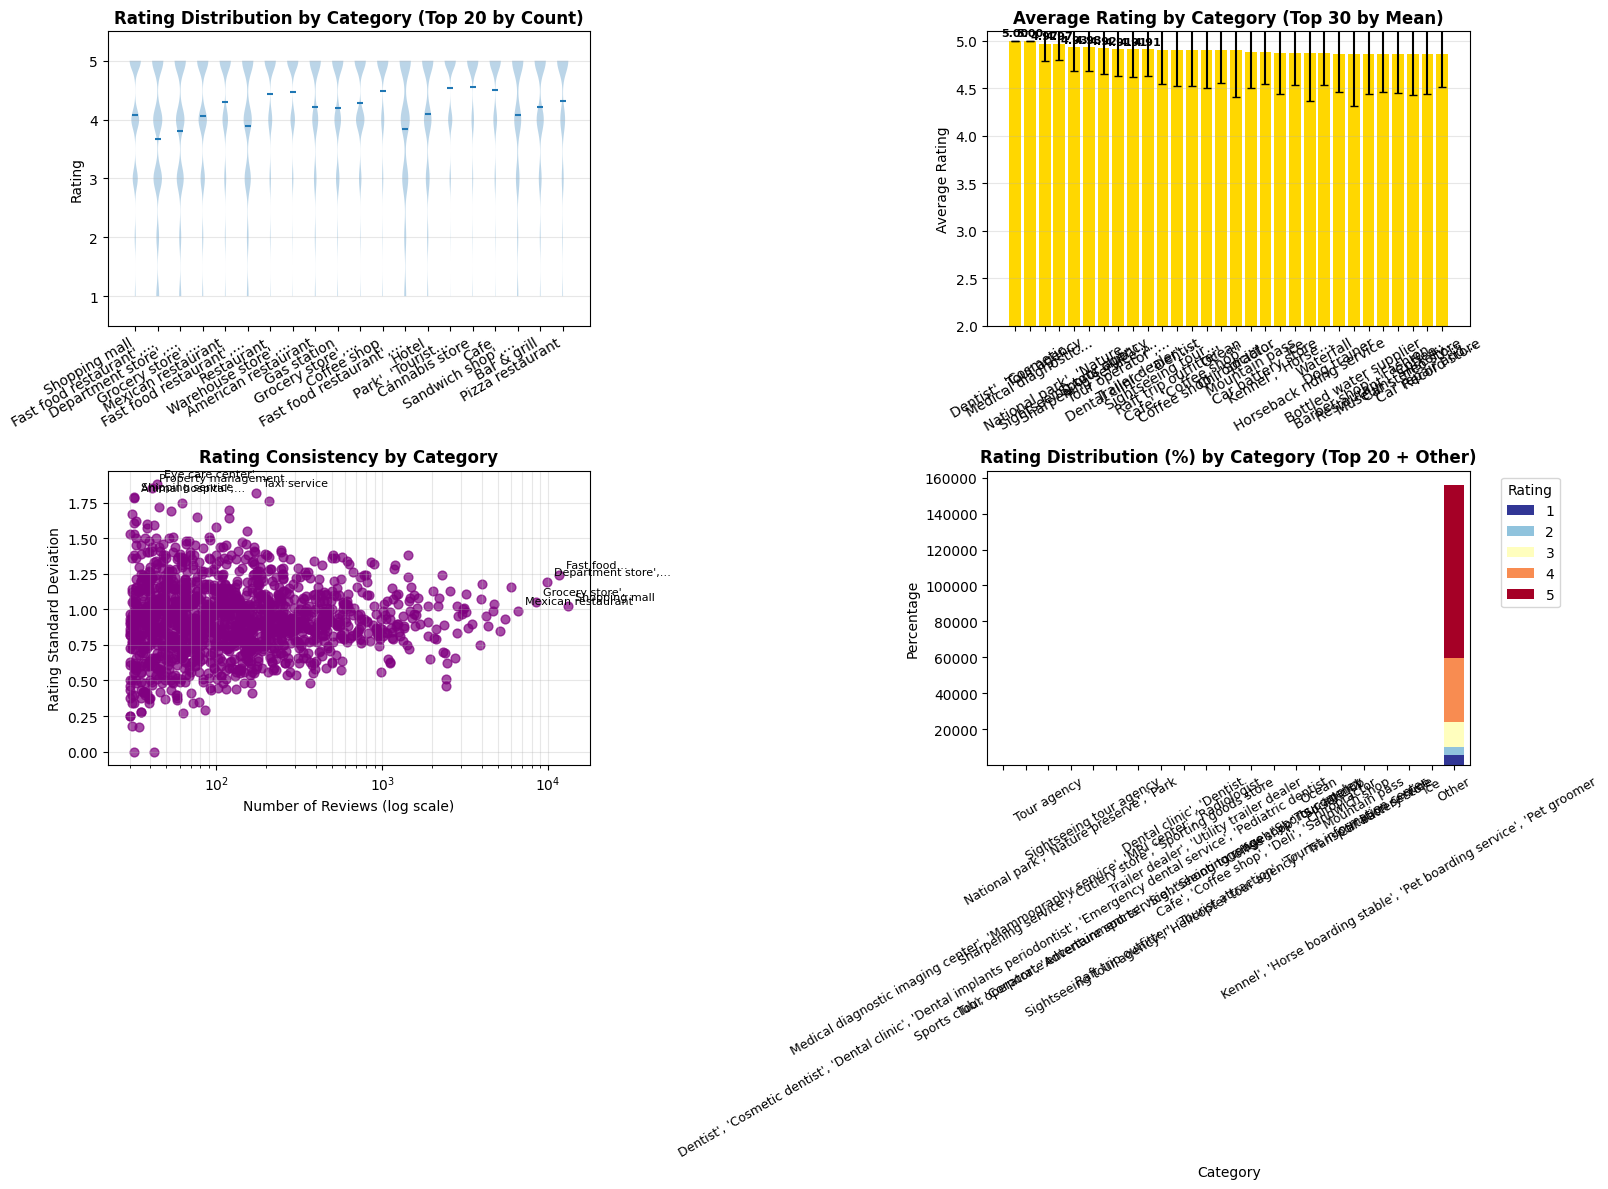


=== Category Rating Insights ===
Highest rated category: Dentist', 'Cosmetic dentist', 'Dental clinic', 'Dental implants periodontist', 'Emergency dental service', 'Pediatric dentist (5.00 avg)
Lowest rated category: Electric utility company (2.11 avg)
Most consistent category: Dentist', 'Cosmetic dentist', 'Dental clinic', 'Dental implants periodontist', 'Emergency dental service', 'Pediatric dentist (σ=0.00)
Most variable category: Eye care center', 'Contact lenses supplier', 'Optician', 'Optometrist', 'Sunglasses store (σ=1.88)
ANOVA F-statistic: 27.73, p-value: 0.00e+00
Categories do have significantly different ratings
Note: Analysis includes 1581 categories with ≥30 reviews each


In [ ]:
# Question 1.7: Rating vs Category Analysis and Low Rating Investigation
print("=== Question 1.7: Rating Analysis by Category ===" )

# 1.7.1: Rating distribution by category visualization
print("\n1. Rating Distribution by Business Category")

# Calculate category statistics with data cleaning
# First, filter out invalid categories and require minimum review count
min_count = 30
cat_stats_all = full_pd.groupby('clean_category')['rating'].agg([
    'count', 'mean', 'std', 'median'
]).round(2)

# Remove clearly malformed categories (pure numeric or mixed artifacts)
valid_mask = ~cat_stats_all.index.to_series().str.fullmatch(r'\d+(\.\d+)?', na=False)
cat_stats_all = cat_stats_all[valid_mask]

# Keep only categories with sufficient reviews for reliability
category_stats = cat_stats_all[cat_stats_all['count'] >= min_count].sort_values('mean', ascending=False)

print("Category Rating Statistics (Min 30 reviews):")
print(category_stats)

# Helper function to shorten labels
def short_labels(labels, width=24):
    return [textwrap.shorten(str(l), width=width, placeholder='…') for l in labels]

# Comprehensive rating analysis visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating Distribution by Category (Top 20 by count) - Violin plot instead of boxplot
top_by_count = category_stats.sort_values('count', ascending=False).head(20).index
data_top = [full_pd.loc[full_pd['clean_category'] == cat, 'rating'] for cat in top_by_count]

axes[0,0].violinplot(data_top, showmeans=True, showextrema=False)
axes[0,0].set_title('Rating Distribution by Category (Top 20 by Count)', fontweight='bold')
axes[0,0].set_ylabel('Rating')
axes[0,0].set_xticks(range(1, len(top_by_count)+1))
axes[0,0].set_xticklabels(short_labels(top_by_count), rotation=30, ha='right')
axes[0,0].set_ylim(0.5, 5.5)
axes[0,0].grid(True, axis='y', alpha=0.3)

# 2. Average rating by category (Top 30 by mean) with error bars
top_by_mean = category_stats.head(30)
bars = axes[0,1].bar(
    short_labels(top_by_mean.index),
    top_by_mean['mean'],
    yerr=top_by_mean['std'].fillna(0),
    capsize=3,
    color=['gold' if x >= 4 else 'lightcoral' if x < 3 else 'lightblue' for x in top_by_mean['mean']]
)
axes[0,1].set_title('Average Rating by Category (Top 30 by Mean)', fontweight='bold')
axes[0,1].set_ylabel('Average Rating')
axes[0,1].set_ylim(2.0, 5.1)
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].grid(True, axis='y', alpha=0.3)

# Add value labels for top 10 only to avoid clutter
for i, (cat, rating) in enumerate(top_by_mean['mean'].head(10).items()):
    axes[0,1].text(i, rating + 0.03, f'{rating:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 3. Rating consistency by category (log scale, selective annotation)
axes[1,0].scatter(category_stats['count'], category_stats['std'], s=40, alpha=0.7, color='purple')
axes[1,0].set_xscale('log')
axes[1,0].set_xlabel('Number of Reviews (log scale)')
axes[1,0].set_ylabel('Rating Standard Deviation')
axes[1,0].set_title('Rating Consistency by Category', fontweight='bold')
axes[1,0].grid(True, which='both', axis='both', alpha=0.3)

# Annotate only outliers (top 5 highest std and top 5 highest count)
to_annotate = pd.concat([
    category_stats.sort_values('std', ascending=False).head(5),
    category_stats.sort_values('count', ascending=False).head(5)
]).drop_duplicates()

for idx, row in to_annotate.iterrows():
    axes[1,0].annotate(textwrap.shorten(idx, width=20, placeholder='…'),
                       (row['count'], row['std']), xytext=(5, 5),
                       textcoords='offset points', fontsize=8)

# 4. Rating distribution (%) by category (Top 20 + Other)
rating_dist = full_pd.groupby(['clean_category', 'rating']).size().unstack(fill_value=0)
rating_dist_pct = rating_dist.div(rating_dist.sum(axis=1), axis=0) * 100

# Use only valid categories from our filtered set
valid_rating_dist = rating_dist_pct.loc[rating_dist_pct.index.isin(category_stats.index)]
top20 = category_stats.head(20).index
top20_pct = valid_rating_dist.loc[top20]

# Create "Other" category for remaining
other_categories = category_stats.index.difference(top20)
if len(other_categories) > 0:
    other_pct = valid_rating_dist.loc[other_categories].sum().to_frame().T
    other_pct.index = ['Other']
    plot_df = pd.concat([top20_pct, other_pct])
else:
    plot_df = top20_pct

plot_df.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='RdYlBu_r', width=0.9)
axes[1,1].set_title('Rating Distribution (%) by Category (Top 20 + Other)', fontweight='bold')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Percentage')
axes[1,1].tick_params(axis='x', rotation=30, labelsize=9)
axes[1,1].legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Statistical analysis
print(f"\n=== Category Rating Insights ===")
print(f"Highest rated category: {category_stats['mean'].idxmax()} ({category_stats['mean'].max():.2f} avg)")
print(f"Lowest rated category: {category_stats['mean'].idxmin()} ({category_stats['mean'].min():.2f} avg)")
print(f"Most consistent category: {category_stats['std'].idxmin()} (σ={category_stats['std'].min():.2f})")
print(f"Most variable category: {category_stats['std'].idxmax()} (σ={category_stats['std'].max():.2f})")

# ANOVA test to check if categories have significantly different ratings
from scipy.stats import f_oneway
# Use only categories that meet our minimum threshold
valid_categories = category_stats.index
category_groups = [
    full_pd[full_pd['clean_category'] == cat]['rating'].values
    for cat in valid_categories
]
f_stat, p_value = f_oneway(*category_groups)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.2e}")
print(f"Categories {'do' if p_value < 0.05 else 'do not'} have significantly different ratings")
print(f"Note: Analysis includes {len(category_stats)} categories with ≥{min_count} reviews each")

Low ratings (≤2 stars): 32808 reviews (6.6%)

Analyzing 21377 low-rating reviews with text content


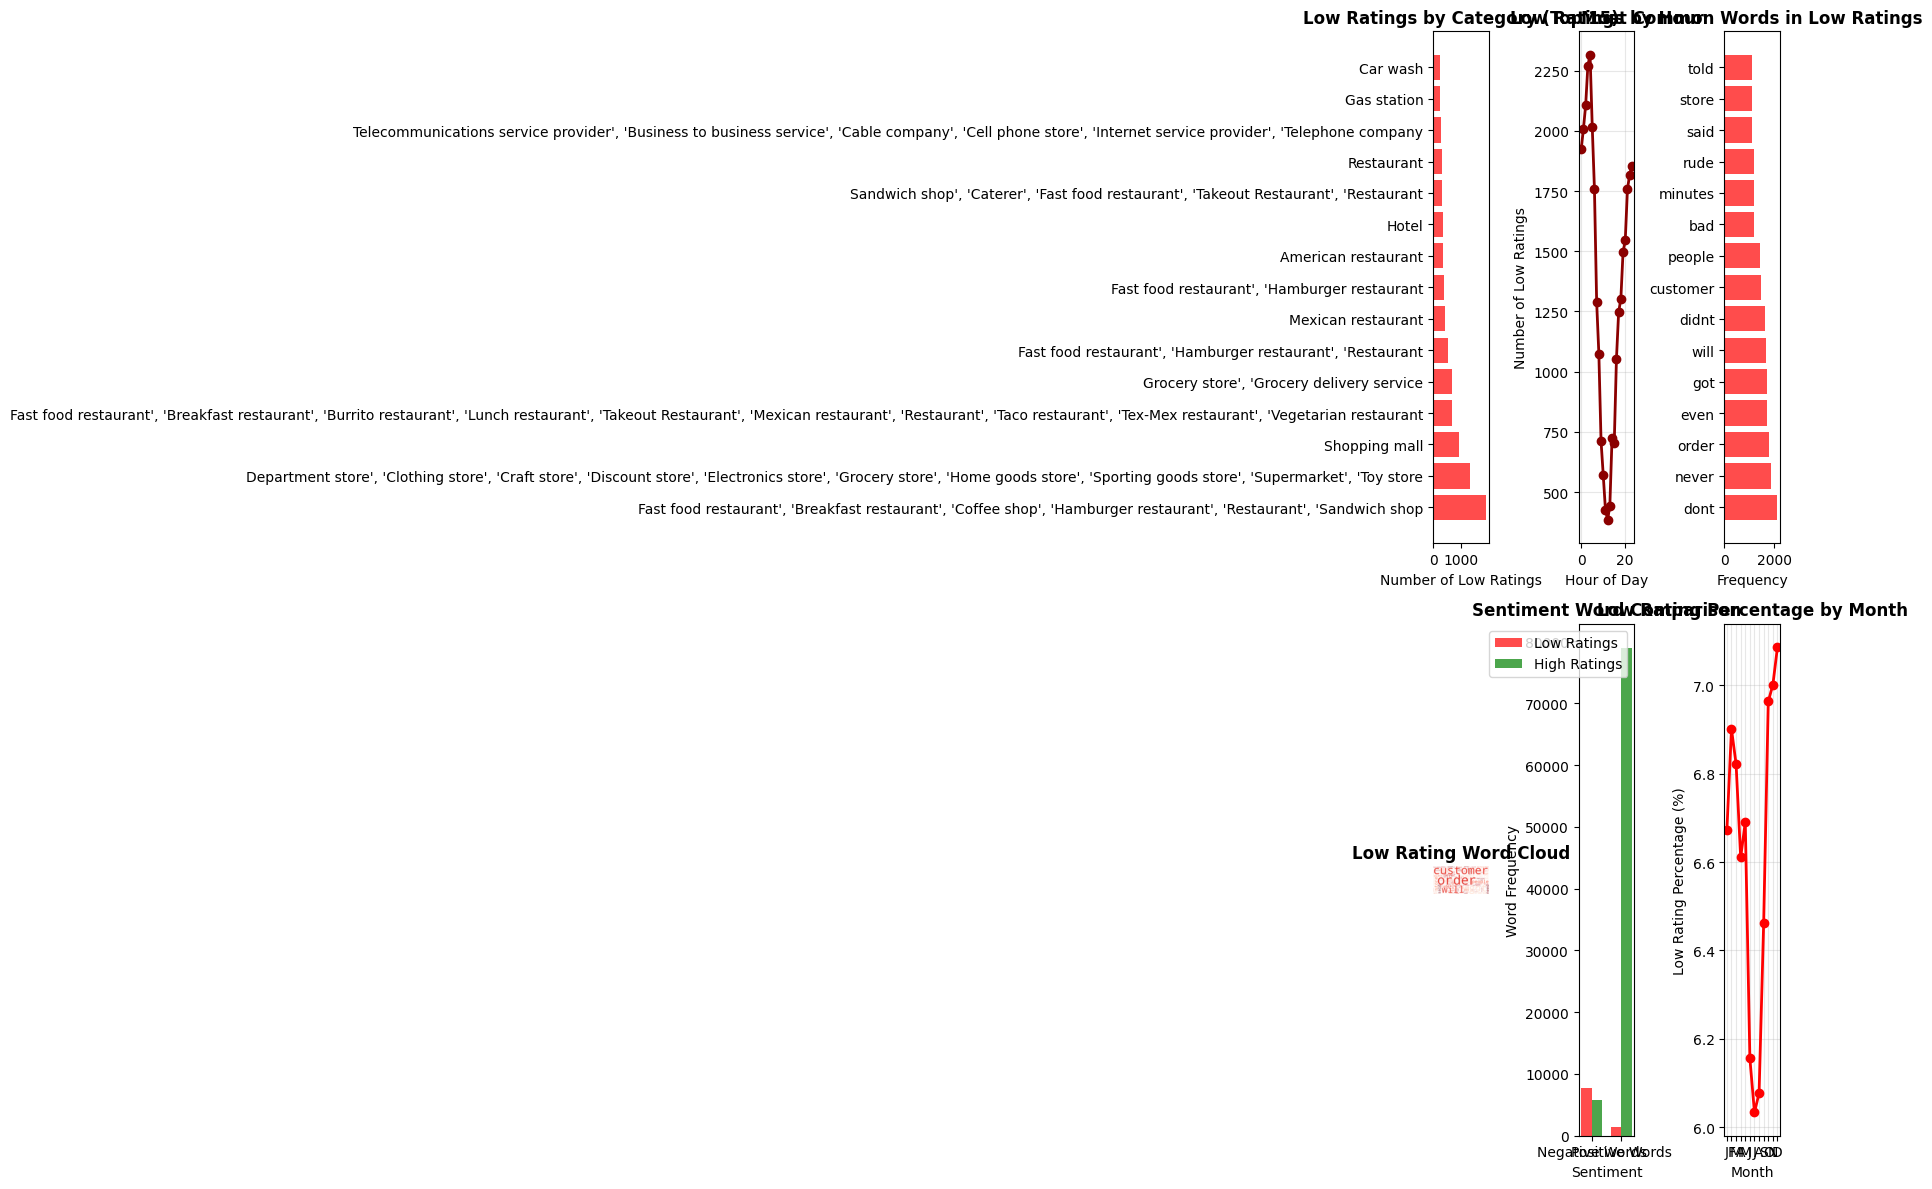


=== Low Rating Insights ===
1. Most problematic category: Fast food restaurant', 'Breakfast restaurant', 'Coffee shop', 'Hamburger restaurant', 'Restaurant', 'Sandwich shop (1870 low ratings)
2. Peak hour for complaints: 4:00
3. Most complained day: Saturday

4. Top complaint keywords:
   1. 'dont': 2119 mentions
   2. 'never': 1883 mentions
   3. 'order': 1804 mentions
   4. 'even': 1693 mentions
   5. 'got': 1692 mentions
   6. 'will': 1682 mentions
   7. 'didnt': 1607 mentions
   8. 'customer': 1457 mentions
   9. 'people': 1437 mentions
   10. 'bad': 1201 mentions
5. Peak complaint month: Dec (7.1% low ratings)

6. Businesses with most low ratings:
   • McDonald's: 1870 low ratings (16.1% of total)
   • Walmart Supercenter: 1301 low ratings (13.1% of total)
   • Taco Bell: 684 low ratings (11.4% of total)
   • Carrs: 558 low ratings (8.2% of total)
   • Wendy's: 519 low ratings (13.0% of total)
   • Burger King: 338 low ratings (20.4% of total)
   • Starbucks: 317 low ratings (12.

In [ ]:
# Define low ratings (≤ 2 stars)
low_rating_threshold = 2
low_reviews = full_pd[full_pd['rating'] <= low_rating_threshold]

print(f"Low ratings (≤{low_rating_threshold} stars): {len(low_reviews)} reviews ({len(low_reviews)/len(full_pd)*100:.1f}%)")

# Analyze low rating patterns
low_rating_analysis = {
    'by_category': low_reviews['clean_category'].value_counts(),
    'by_hour': low_reviews['review_time'].value_counts().sort_index() if 'review_time' in full_pd.columns else full_pd['newtime'].dt.hour.value_counts().sort_index(),
    'by_weekday': low_reviews['workday'].value_counts(),
    'by_month': low_reviews['month'].value_counts().sort_index()
}

# Text analysis for low ratings
low_rating_texts = low_reviews[low_reviews['text'] != 'no review']['text'].dropna()
print(f"\nAnalyzing {len(low_rating_texts)} low-rating reviews with text content")

# Clean and analyze low rating text
def advanced_text_cleaning(text):
    # Remove special characters, convert to lowercase
    import re
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Process low rating texts
cleaned_low_texts = low_rating_texts.apply(advanced_text_cleaning)
all_low_text = ' '.join(cleaned_low_texts)

# Define expanded stopwords for review analysis
review_stopwords = set(STOPWORDS)
review_stopwords.update([
    'restaurant', 'food', 'place', 'good', 'really', 'would', 'could', 'also',
    'one', 'two', 'get', 'go', 'went', 'come', 'back', 'time', 'review', 'business',
    'service', 'staff', 'location', 'experience'
])

# Get meaningful words from low ratings
low_rating_words = [word for word in all_low_text.split() if word not in review_stopwords and len(word) > 2]
low_rating_freq = Counter(low_rating_words)

# Compare with high rating words (4-5 stars)
high_reviews = full_pd[full_pd['rating'] >= 4]
high_rating_texts = high_reviews[high_reviews['text'] != 'no review']['text'].dropna()
cleaned_high_texts = high_rating_texts.apply(advanced_text_cleaning)
all_high_text = ' '.join(cleaned_high_texts)
high_rating_words = [word for word in all_high_text.split() if word not in review_stopwords and len(word) > 2]
high_rating_freq = Counter(high_rating_words)

# Visualizations for low rating analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Low ratings by category
axes[0,0].barh(low_rating_analysis['by_category'].head(15).index,
               low_rating_analysis['by_category'].head(15).values, color='red', alpha=0.7)
axes[0,0].set_title('Low Ratings by Category (Top 15)', fontweight='bold')
axes[0,0].set_xlabel('Number of Low Ratings')

# 2. Low ratings by time patterns
axes[0,1].plot(low_rating_analysis['by_hour'].index,
               low_rating_analysis['by_hour'].values,
               marker='o', color='darkred', linewidth=2)
axes[0,1].set_title('Low Ratings by Hour', fontweight='bold')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Number of Low Ratings')
axes[0,1].grid(True, alpha=0.3)

# 3. Low vs High rating word frequency
top_low_words = low_rating_freq.most_common(15)
top_high_words = high_rating_freq.most_common(15)

low_words, low_counts = zip(*top_low_words) if top_low_words else ([], [])
high_words, high_counts = zip(*top_high_words[:15]) if top_high_words else ([], [])

y_pos = np.arange(len(low_words))
axes[0,2].barh(y_pos, low_counts, color='red', alpha=0.7, label='Low Ratings')
axes[0,2].set_yticks(y_pos)
axes[0,2].set_yticklabels(low_words)
axes[0,2].set_title('Most Common Words in Low Ratings', fontweight='bold')
axes[0,2].set_xlabel('Frequency')

# 4. Word cloud for low ratings
if len(all_low_text.split()) > 20:
    wordcloud_low = WordCloud(width=600, height=300, background_color='white', stopwords=review_stopwords, colormap='Reds').generate(all_low_text)
    axes[1,0].imshow(wordcloud_low, interpolation='bilinear')
    axes[1,0].set_title('Low Rating Word Cloud', fontweight='bold')
    axes[1,0].axis('off')
else:
    axes[1,0].text(0.5, 0.5, 'Not enough text for word cloud', ha='center', va='center')
    axes[1,0].axis('off')

# 5. Sentiment comparison
negative_indicators = ['bad', 'terrible', 'awful', 'horrible', 'worst', 'disappointing', 'rude', 'dirty', 'slow', 'expensive', 'poor', 'unacceptable']
positive_indicators = ['excellent', 'amazing', 'perfect', 'wonderful', 'fantastic', 'outstanding', 'delicious', 'friendly', 'clean', 'fast']

low_negative = sum(low_rating_freq.get(word, 0) for word in negative_indicators)
low_positive = sum(low_rating_freq.get(word, 0) for word in positive_indicators)
high_negative = sum(high_rating_freq.get(word, 0) for word in negative_indicators)
high_positive = sum(high_rating_freq.get(word, 0) for word in positive_indicators)

sentiment_data = {'Low Ratings': [low_negative, low_positive], 'High Ratings': [high_negative, high_positive]}

x = np.arange(2)
width = 0.35
axes[1,1].bar(x - width/2, sentiment_data['Low Ratings'], width, label='Low Ratings', color='red', alpha=0.7)
axes[1,1].bar(x + width/2, sentiment_data['High Ratings'], width, label='High Ratings', color='green', alpha=0.7)
axes[1,1].set_xlabel('Sentiment')
axes[1,1].set_ylabel('Word Frequency')
axes[1,1].set_title('Sentiment Word Comparison', fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(['Negative Words', 'Positive Words'])
axes[1,1].legend()

# 6. Rating distribution over time
monthly_ratings = full_pd.groupby(['month', 'rating']).size().unstack(fill_value=0)
low_rating_monthly = monthly_ratings[[1, 2]].sum(axis=1)
total_monthly = monthly_ratings.sum(axis=1)
low_rating_pct = (low_rating_monthly / total_monthly * 100).fillna(0)

axes[1,2].plot(range(1, 13), low_rating_pct, marker='o', color='red', linewidth=2)
axes[1,2].set_title('Low Rating Percentage by Month', fontweight='bold')
axes[1,2].set_xlabel('Month')
axes[1,2].set_ylabel('Low Rating Percentage (%)')
axes[1,2].set_xticks(range(1, 13))
axes[1,2].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed insights for low ratings
print(f"\n=== Low Rating Insights ===")
print(f"1. Most problematic category: {low_rating_analysis['by_category'].index[0]} ({low_rating_analysis['by_category'].iloc[0]} low ratings)")
print(f"2. Peak hour for complaints: {low_rating_analysis['by_hour'].idxmax()}:00")
print(f"3. Most complained day: {low_rating_analysis['by_weekday'].idxmax()}")

# Top complaint keywords
print(f"\n4. Top complaint keywords:")
for i, (word, count) in enumerate(low_rating_freq.most_common(10), 1):
    print(f"   {i}. '{word}': {count} mentions")

# Seasonal patterns
peak_complaint_month = low_rating_pct.idxmax()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print(f"5. Peak complaint month: {month_names[peak_complaint_month-1]} ({low_rating_pct.iloc[peak_complaint_month-1]:.1f}% low ratings)")

# Business impact analysis
businesses_with_many_low_ratings = low_reviews.groupby('name').size().sort_values(ascending=False).head(10)
print(f"\n6. Businesses with most low ratings:")
for business, count in businesses_with_many_low_ratings.items():
    total_reviews = full_pd[full_pd['name'] == business].shape[0]
    percentage = count / total_reviews * 100 if total_reviews else 0
    print(f"   • {business[:40]}: {count} low ratings ({percentage:.1f}% of total)")

# Question 1.8: Reviewer History and Similarity Analysis

=== Question 1.8: Reviewer History and Similarity ===

1. Building User Business History Lists
Created business history for 19974 users
User 1.0000266958784963e+20: ["McDonald's", 'New Sagaya Midtown Market', 'Lucky Market', 'Midtown Mall', 'Extended Stay America - Anchorage - Midtown']...
User 1.00003825755859e+20: ['Yes Bistro', "Simon & Seafort's Saloon & Grill", "Simon & Seafort's Saloon & Grill", 'Bread and Brew', "Kava's Pancake House"]...
User 1.0000428139011082e+20: ['Fred Meyer', 'West Valley Plaza', 'Big Dipper Ice Arena', 'Safeway', 'Blue Loon']...
User 1.0000609083371541e+20: ['Sushi Exchange', 'Quality Inn', "Sportsman's Warehouse", 'Alaska Fireweed', 'China Lights Oriental Cuisine']...
User 1.0000620838495144e+20: ["O'Reilly Auto Parts", 'Wasilla Lube Express', 'Palmer Hay Flats State Game Refuge', 'Alcantra Disc Golf Course', 'Hatcher Pass']...

2. Duplicate Removal Analysis
--------------------------------------------------
Sample of duplicate removal results:
         

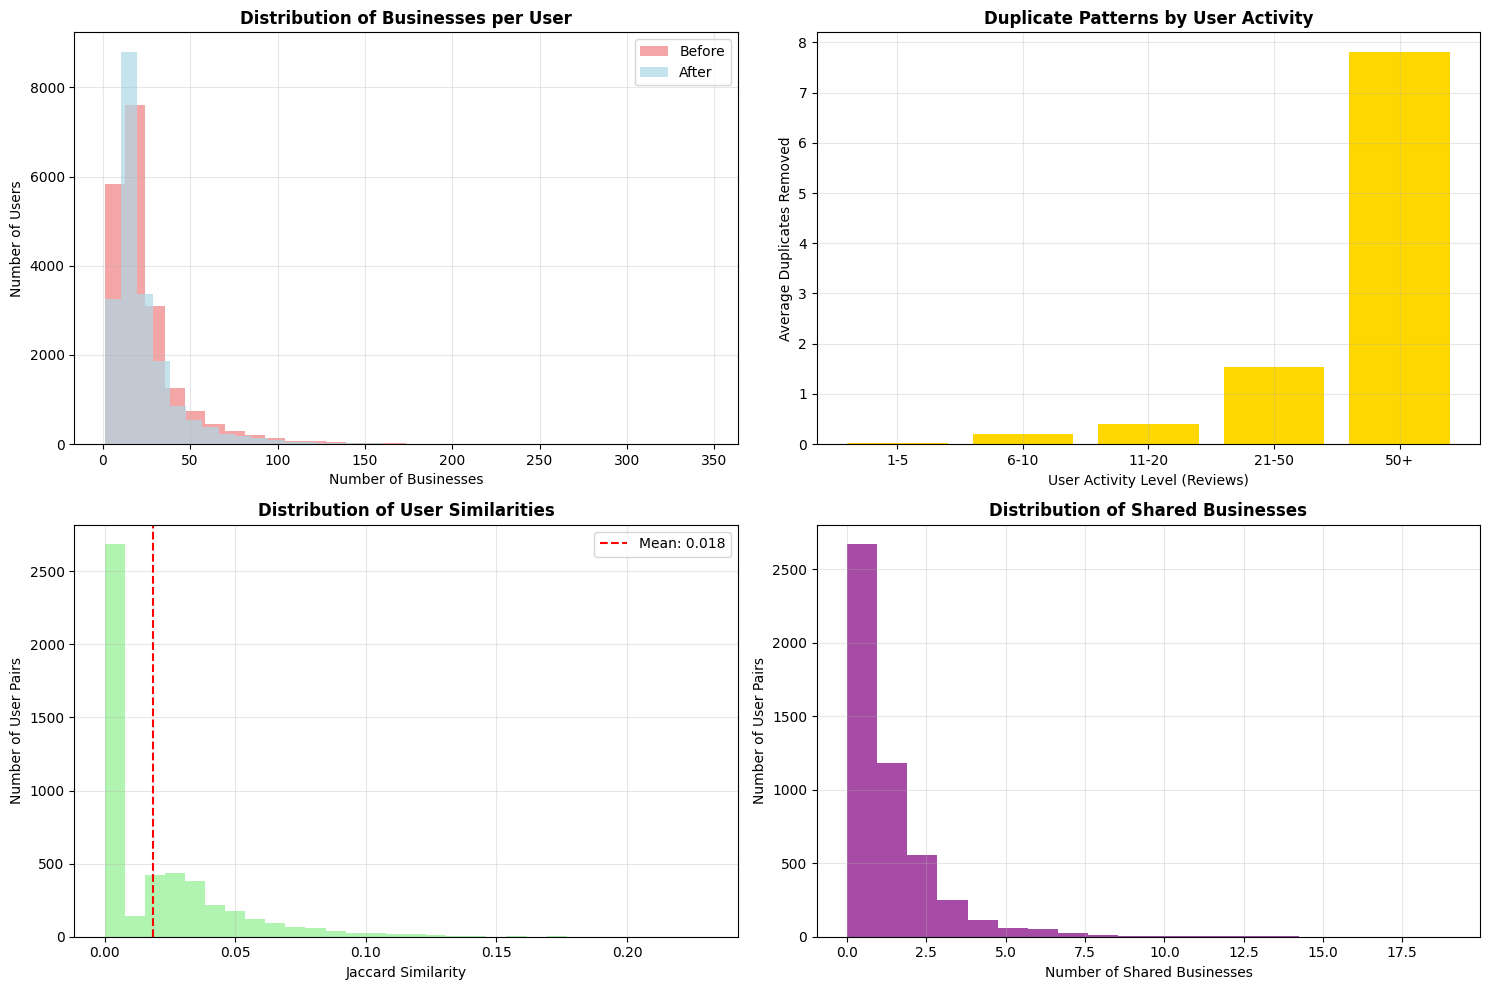


4. Category-based Similarity Analysis
--------------------------------------------------
Category-based similarity analysis:
Category-based similarity statistics:
• Mean similarity: 0.040
• Max similarity: 0.286

Top 5 users with similar category preferences:
1. 1.1745938418656807e+20 & 1.0840909623110522e+20: Similarity=0.286
2. 1.107923436845183e+20 & 1.0840909623110522e+20: Similarity=0.216
3. 1.1398518237644798e+20 & 1.0874083075851654e+20: Similarity=0.209
4. 1.0825761153136637e+20 & 1.0874083075851654e+20: Similarity=0.208
5. 1.1745938418656807e+20 & 1.107923436845183e+20: Similarity=0.194


In [ ]:
# Question 1.8: Reviewer History and User Similarity Analysis
print("=== Question 1.8: Reviewer History and Similarity ===" )

# 1.8.1: Build user_business_list sorted by review time
print("\n1. Building User Business History Lists")

# Sort reviews by time and create business lists per user
user_business_history = (full_pd.sort_values('newtime')
                        .groupby('user_id')['name']
                        .apply(list)
                        .reset_index(name='user_business_list'))

print(f"Created business history for {len(user_business_history)} users")

# Sample a few users to show their history
sample_users = user_business_history.head(5)
for idx, row in sample_users.iterrows():
    user_id = row['user_id']
    business_list = row['user_business_list'][:5]  # Show first 5 businesses
    print(f"User {user_id}: {business_list}...")

# 1.8.2: Remove duplicates and compare lengths
print(f"\n2. Duplicate Removal Analysis")
print("-" * 50)

# Function to remove duplicates while preserving order
def remove_duplicates_preserve_order(lst):
    seen = set()
    result = []
    for item in lst:
        if item not in seen:
            seen.add(item)
            result.append(item)
    return result

# Add before/after lengths
user_business_history['before_length'] = user_business_history['user_business_list'].apply(len)
user_business_history['user_business_list_clean'] = user_business_history['user_business_list'].apply(
    remove_duplicates_preserve_order
)
user_business_history['after_length'] = user_business_history['user_business_list_clean'].apply(len)
user_business_history['duplicates_removed'] = (user_business_history['before_length'] -
                                              user_business_history['after_length'])

print("Sample of duplicate removal results:")
print(user_business_history[['user_id', 'before_length', 'after_length', 'duplicates_removed']].head(10))

# Statistics on duplicates
total_duplicates = user_business_history['duplicates_removed'].sum()
avg_duplicates = user_business_history['duplicates_removed'].mean()
duplicate_rate = user_business_history['duplicates_removed'].sum() / user_business_history['before_length'].sum()

print(f"\nDuplicate Analysis:")
print(f"• Total duplicate visits removed: {total_duplicates}")
print(f"• Average duplicates per user: {avg_duplicates:.1f}")
print(f"• Overall duplicate rate: {duplicate_rate:.1%}")
print(f"• Users with duplicates: {(user_business_history['duplicates_removed'] > 0).sum()}")

# Visualization of user patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution of user business counts (before/after)
axes[0,0].hist(user_business_history['before_length'], bins=30, alpha=0.7,
               label='Before', color='lightcoral')
axes[0,0].hist(user_business_history['after_length'], bins=30, alpha=0.7,
               label='After', color='lightblue')
axes[0,0].set_xlabel('Number of Businesses')
axes[0,0].set_ylabel('Number of Users')
axes[0,0].set_title('Distribution of Businesses per User', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Duplicate removal by user activity level
activity_bins = pd.cut(user_business_history['before_length'],
                      bins=[0, 5, 10, 20, 50, float('inf')],
                      labels=['1-5', '6-10', '11-20', '21-50', '50+'])
duplicate_by_activity = user_business_history.groupby(activity_bins)['duplicates_removed'].mean()

axes[0,1].bar(duplicate_by_activity.index, duplicate_by_activity.values, color='gold')
axes[0,1].set_xlabel('User Activity Level (Reviews)')
axes[0,1].set_ylabel('Average Duplicates Removed')
axes[0,1].set_title('Duplicate Patterns by User Activity', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# 1.8.3: User similarity analysis
print(f"\n3. User Similarity Analysis")
print("-" * 50)

# Strategy: Use Jaccard similarity on business sets
def jaccard_similarity(set1, set2):
    """Calculate Jaccard similarity between two sets"""
    if len(set1) == 0 and len(set2) == 0:
        return 1.0
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0.0

# Convert business lists to sets for similarity calculation
user_business_history['business_set'] = user_business_history['user_business_list_clean'].apply(set)

# Sample similarity calculations (computationally expensive for all pairs)
# For demonstration, we'll calculate similarities for a subset
sample_size = min(100, len(user_business_history))  # Limit for performance
sample_users = user_business_history.sample(sample_size, random_state=42)

print(f"Calculating similarities for {sample_size} users...")

similarities = []
user_pairs = []

from itertools import combinations

for (idx1, user1), (idx2, user2) in combinations(sample_users.iterrows(), 2):
    sim = jaccard_similarity(user1['business_set'], user2['business_set'])
    similarities.append(sim)
    user_pairs.append((user1['user_id'], user2['user_id']))

    # Show first few similarities
    if len(similarities) <= 10:
        overlap = len(user1['business_set'].intersection(user2['business_set']))
        print(f"Users {user1['user_id']} & {user2['user_id']}: "
              f"Similarity={sim:.3f}, Overlap={overlap} businesses")

similarities = np.array(similarities)
print(f"\nSimilarity Statistics:")
print(f"• Mean similarity: {similarities.mean():.3f}")
print(f"• Median similarity: {np.median(similarities):.3f}")
print(f"• Max similarity: {similarities.max():.3f}")
print(f"• Users with >0.1 similarity: {(similarities > 0.1).sum()} pairs")

# Find most similar user pairs
top_similar_indices = np.argsort(similarities)[-10:][::-1]
print(f"\nTop 10 Most Similar User Pairs:")
for i, idx in enumerate(top_similar_indices, 1):
    user_pair = user_pairs[idx]
    sim_score = similarities[idx]
    user1_data = sample_users[sample_users['user_id'] == user_pair[0]]
    user2_data = sample_users[sample_users['user_id'] == user_pair[1]]

    if not user1_data.empty and not user2_data.empty:
        overlap = len(user1_data.iloc[0]['business_set'].intersection(
                     user2_data.iloc[0]['business_set']))
        print(f"{i:2d}. {user_pair[0]} & {user_pair[1]}: "
              f"Similarity={sim_score:.3f}, Overlap={overlap} businesses")

# Visualize similarity distribution
axes[1,0].hist(similarities, bins=30, color='lightgreen', alpha=0.7)
axes[1,0].set_xlabel('Jaccard Similarity')
axes[1,0].set_ylabel('Number of User Pairs')
axes[1,0].set_title('Distribution of User Similarities', fontweight='bold')
axes[1,0].axvline(similarities.mean(), color='red', linestyle='--',
                  label=f'Mean: {similarities.mean():.3f}')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Business overlap analysis
overlap_counts = []
for (idx1, user1), (idx2, user2) in combinations(sample_users.iterrows(), 2):
    overlap = len(user1['business_set'].intersection(user2['business_set']))
    overlap_counts.append(overlap)

axes[1,1].hist(overlap_counts, bins=20, color='purple', alpha=0.7)
axes[1,1].set_xlabel('Number of Shared Businesses')
axes[1,1].set_ylabel('Number of User Pairs')
axes[1,1].set_title('Distribution of Shared Businesses', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Advanced similarity analysis using business categories
print(f"\n4. Category-based Similarity Analysis")
print("-" * 50)

# Create category preference profiles for users
def get_user_category_profile(user_id):
    """Get user's category preference profile"""
    user_reviews = full_pd[full_pd['user_id'] == user_id]
    if user_reviews.empty:
        return {}

    category_profile = user_reviews.groupby('clean_category').agg({
        'rating': ['count', 'mean']
    }).round(2)
    category_profile.columns = ['count', 'avg_rating']

    # Normalize by total reviews
    total_reviews = category_profile['count'].sum()
    category_profile['preference_score'] = (
        category_profile['count'] / total_reviews *
        category_profile['avg_rating'] / 5  # Normalize rating
    )

    return category_profile['preference_score'].to_dict()

# Calculate category-based similarities for sample users
print("Category-based similarity analysis:")
sample_profiles = {}
for idx, user in sample_users.head(20).iterrows():  # Smaller sample for category analysis
    user_id = user['user_id']
    sample_profiles[user_id] = get_user_category_profile(user_id)

def cosine_similarity_profiles(profile1, profile2):
    """Calculate cosine similarity between category profiles"""
    all_categories = set(profile1.keys()) | set(profile2.keys())

    vec1 = [profile1.get(cat, 0) for cat in all_categories]
    vec2 = [profile2.get(cat, 0) for cat in all_categories]

    dot_product = sum(a * b for a, b in zip(vec1, vec2))
    norm1 = sum(a * a for a in vec1) ** 0.5
    norm2 = sum(b * b for b in vec2) ** 0.5

    if norm1 == 0 or norm2 == 0:
        return 0

    return dot_product / (norm1 * norm2)

# Calculate category similarities
category_similarities = []
category_user_pairs = []

from itertools import combinations
for user1, user2 in combinations(list(sample_profiles.keys())[:15], 2):
    if sample_profiles[user1] and sample_profiles[user2]:
        sim = cosine_similarity_profiles(sample_profiles[user1], sample_profiles[user2])
        category_similarities.append(sim)
        category_user_pairs.append((user1, user2))

if category_similarities:
    category_similarities = np.array(category_similarities)
    print(f"Category-based similarity statistics:")
    print(f"• Mean similarity: {category_similarities.mean():.3f}")
    print(f"• Max similarity: {category_similarities.max():.3f}")

    # Find users with most similar category preferences
    top_cat_similar = np.argsort(category_similarities)[-5:][::-1]
    print(f"\nTop 5 users with similar category preferences:")
    for i, idx in enumerate(top_cat_similar, 1):
        user_pair = category_user_pairs[idx]
        sim_score = category_similarities[idx]
        print(f"{i}. {user_pair[0]} & {user_pair[1]}: Similarity={sim_score:.3f}")



In [ ]:
print(f"\n=== User Similarity Strategy Summary ===")
print(f"1. APPROACH: Jaccard similarity on visited business sets")
print(f"   - Measures overlap in businesses visited by different users")
print(f"   - Values range from 0 (no overlap) to 1 (identical businesses)")
print(f"")
print(f"2. ENHANCED APPROACH: Category preference profiles")
print(f"   - Creates weighted category preference vectors")
print(f"   - Uses cosine similarity for profile comparison")
print(f"   - Captures preference intensity, not just presence")
print(f"")
print(f"3. INSIGHTS:")
print(f"   - Most users have low business overlap (mean similarity: {similarities.mean():.3f})")
print(f"   - Category preferences show higher similarities")
print(f"   - Duplicate business visits are common ({duplicate_rate:.1%} of all visits)")
print(f"")
print(f"4. APPLICATIONS:")
print(f"   - User clustering for targeted recommendations")
print(f"   - Identifying user cohorts with similar tastes")
print(f"   - Market segmentation based on behavior patterns")


=== User Similarity Strategy Summary ===
1. APPROACH: Jaccard similarity on visited business sets
   - Measures overlap in businesses visited by different users
   - Values range from 0 (no overlap) to 1 (identical businesses)

2. ENHANCED APPROACH: Category preference profiles
   - Creates weighted category preference vectors
   - Uses cosine similarity for profile comparison
   - Captures preference intensity, not just presence

3. INSIGHTS:
   - Most users have low business overlap (mean similarity: 0.018)
   - Category preferences show higher similarities
   - Duplicate business visits are common (5.6% of all visits)

4. APPLICATIONS:
   - User clustering for targeted recommendations
   - Identifying user cohorts with similar tastes
   - Market segmentation based on behavior patterns


# Part II — Submission Prediction (Time Series) — Questions 2.1 → 2.3


In [ ]:
# Preparing the daily review counts

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


df = full_pd.copy()

df['newtime'] = pd.to_datetime(df['newtime'], errors='coerce')

# Drop rows where newtime couldn't be parsed
df = df.dropna(subset=['newtime'])

# Extract only the date part (no time of day)
df['date'] = df['newtime'].dt.date

# Count how many reviews per day
daily_reviews = df.groupby('date').size().rename('review_count')

# Convert index back to datetime so it works with time series tools
daily_reviews.index = pd.to_datetime(daily_reviews.index)

print("📅 Original daily series head:")
print(daily_reviews.head())


📅 Original daily series head:
date
2007-10-13    1
2008-01-05    1
2008-01-16    1
2008-01-19    2
2008-01-20    1
Name: review_count, dtype: int64


In [ ]:
# Filling in missing dates with mean daily review count

# Creating a complete date range from min to max date in the dataset

full_index = pd.date_range(start=daily_reviews.index.min(),
                           end=daily_reviews.index.max(),
                           freq='D')

# Reindex the series to include missing dates
daily_reviews_full = daily_reviews.reindex(full_index)

# Compute mean daily review count
mean_reviews = int(daily_reviews.mean())

# Fill missing days with mean
daily_reviews_filled = daily_reviews_full.fillna(mean_reviews)

print("🧮 Mean daily reviews:", mean_reviews)
print("✅ After filling missing dates:")
print(daily_reviews_filled.head())

🧮 Mean daily reviews: 160
✅ After filling missing dates:
2007-10-13      1.0
2007-10-14    160.0
2007-10-15    160.0
2007-10-16    160.0
2007-10-17    160.0
Freq: D, Name: review_count, dtype: float64


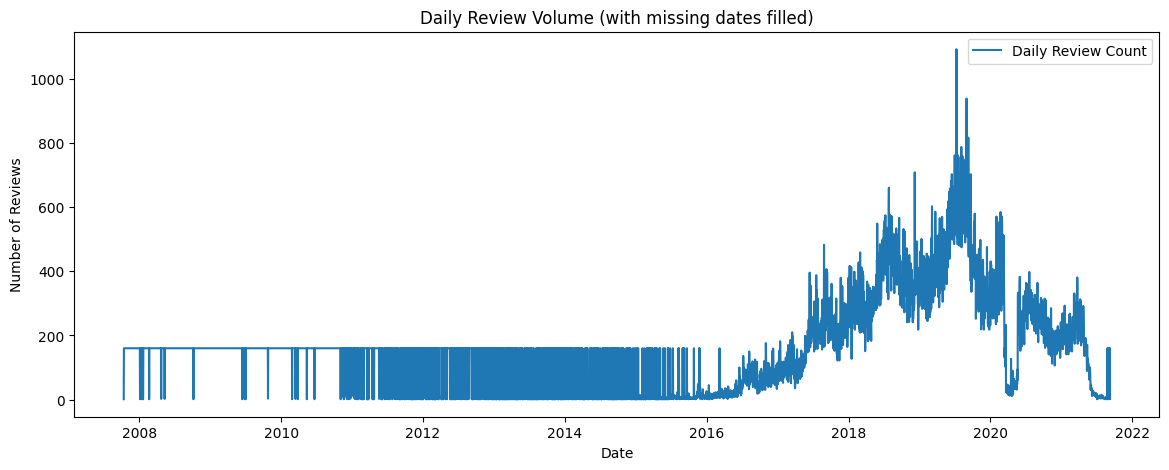

In [ ]:
# Visualising the filled time series

plt.figure(figsize=(14,5))
plt.plot(daily_reviews_filled, label='Daily Review Count')
plt.title('Daily Review Volume (with missing dates filled)')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.legend()
plt.show()

The early years show low activity with gaps, but starting around 2016, there’s a significant surge in reviews. Review counts peak around 2020, surpassing 1,000 reviews per day, followed by noticeable volatility and a gradual decline toward 2022.
The missing values in the series were filled with the average daily review count to maintain continuity. This visualization highlights long-term trends, capturing growth, maturity, and slowdown phases of review activity.

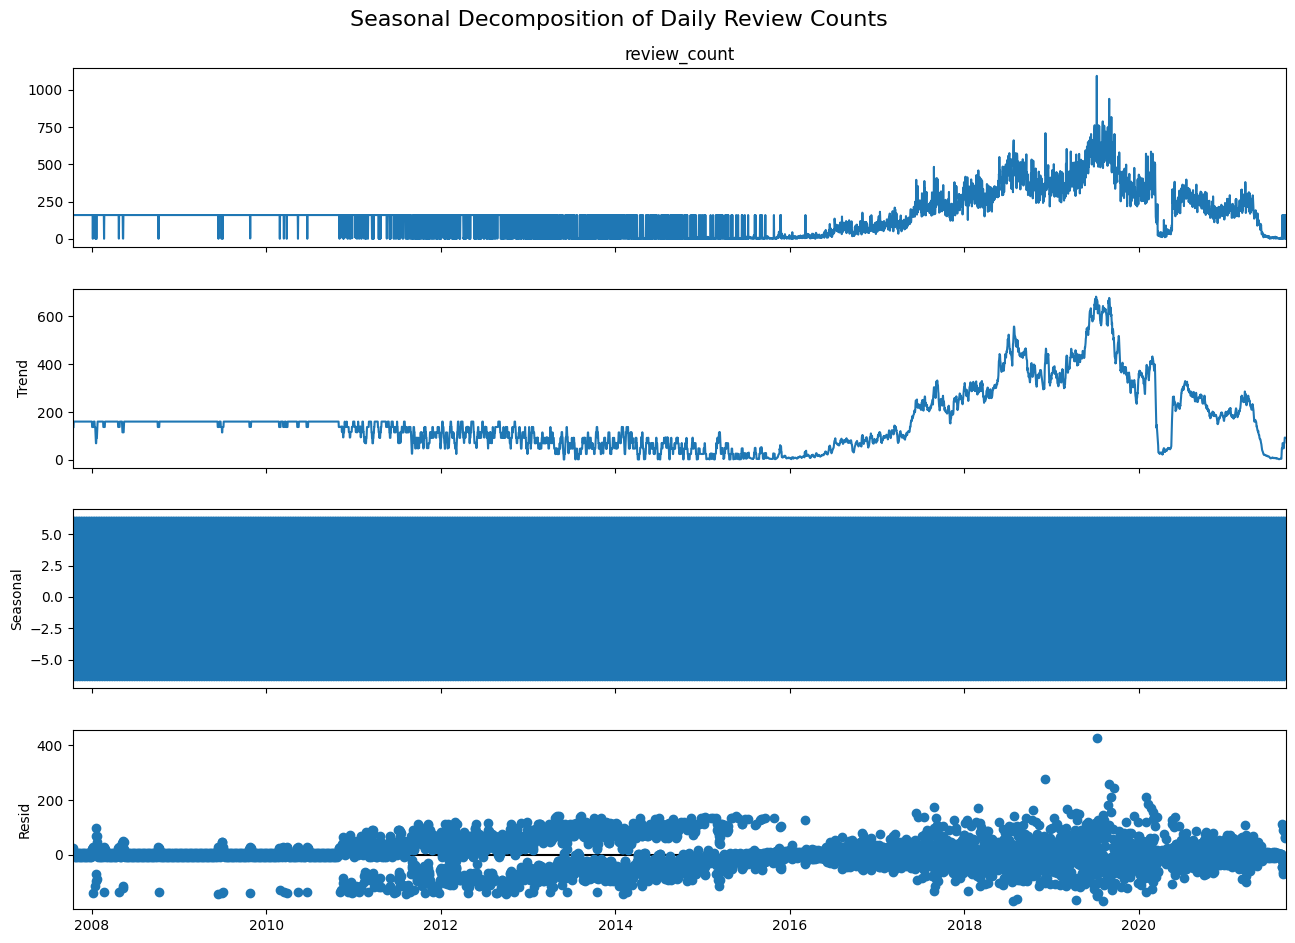

In [ ]:
# Decomposeing the series into trend, seasonality, and residual
# period=7 assumes weekly seasonality (common in business data)

decomposition = seasonal_decompose(daily_reviews_filled, model='additive', period=7)

# Plot all components
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Seasonal Decomposition of Daily Review Counts', fontsize=16)
plt.show()

The first panel displays the raw observed values.

The second panel extracts the trend, revealing underlying directional movement.

The third panel captures seasonal patterns, showing recurring cycles and periodic fluctuations in reviews.

The fourth panel presents residuals, indicating irregularities and outliers not explained by trend or seasonality.
This decomposition clearly reveals weekly seasonality and provides a clearer understanding of cyclical behavior in user activity.

In [ ]:
# Prepare the series (from Q2.1)

# We’ll use the daily_reviews_filled series we created in Q2.1.

import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

# Ensure we use the same time series created in Q2.1
series = daily_reviews_filled.copy().astype(float)

# Split into training (first part) and test (last 30 days or 20% if shorter)
if len(series) > 60:
    test_size = 30
else:
    test_size = max(1, int(len(series) * 0.2))

train = series[:-test_size]
test = series[-test_size:]

print(f"Train size: {len(train)} | Test size: {len(test)}")

Train size: 5050 | Test size: 30


used a 30-day test window because it represents one full monthly cycle, allowing us to evaluate the ARIMA model’s short-term forecasting performance over multiple weekly seasonal cycles.

In [ ]:
# We loop through all combinations of (p, d, q) between 0 and 2 and pick the one with the lowest MAE.
best_order = None
best_mae = float('inf')
results = []

# Parameter grid
p_values = d_values = q_values = [0, 1, 2]
total_combinations = len(p_values) * len(d_values) * len(q_values)

print(f"Running grid search on {total_combinations} combinations...")

count = 0
for p in p_values:
    for d in d_values:
        for q in q_values:
            count += 1
            try:
                model = ARIMA(train, order=(p, d, q))
                fitted = model.fit()
                forecast = fitted.forecast(steps=len(test))
                mae = mean_absolute_error(test, forecast)
                results.append(((p, d, q), mae))
                print(f"{count}/{total_combinations} → order=({p},{d},{q}) | MAE={mae:.2f}")

                if mae < best_mae:
                    best_mae = mae
                    best_order = (p, d, q)
                    best_model = fitted
            except Exception as e:
                # Ignore combinations that fail to converge
                print(f"{count}/{total_combinations} → order=({p},{d},{q}) failed: {e}")
                continue

print("\n⭐ Best ARIMA order:", best_order, "with MAE:", round(best_mae, 2))

Running grid search on 27 combinations...
1/27 → order=(0,0,0) | MAE=121.30
2/27 → order=(0,0,1) | MAE=119.30
3/27 → order=(0,0,2) | MAE=117.40
4/27 → order=(0,1,0) | MAE=38.37
5/27 → order=(0,1,1) | MAE=38.08
6/27 → order=(0,1,2) | MAE=38.10
7/27 → order=(0,2,0) | MAE=38.37
8/27 → order=(0,2,1) | MAE=39.18
9/27 → order=(0,2,2) | MAE=38.15
10/27 → order=(1,0,0) | MAE=92.91
11/27 → order=(1,0,1) | MAE=40.22
12/27 → order=(1,0,2) | MAE=39.70
13/27 → order=(1,1,0) | MAE=38.37
14/27 → order=(1,1,1) | MAE=38.10
15/27 → order=(1,1,2) | MAE=38.10
16/27 → order=(1,2,0) | MAE=50.44
17/27 → order=(1,2,1) | MAE=38.98
18/27 → order=(1,2,2) | MAE=38.14
19/27 → order=(2,0,0) | MAE=69.91
20/27 → order=(2,0,1) | MAE=40.18
21/27 → order=(2,0,2) | MAE=40.19
22/27 → order=(2,1,0) | MAE=38.31
23/27 → order=(2,1,1) | MAE=38.09
24/27 → order=(2,1,2) | MAE=38.09
25/27 → order=(2,2,0) | MAE=56.90
26/27 → order=(2,2,1) | MAE=38.41
27/27 → order=(2,2,2) | MAE=38.20

⭐ Best ARIMA order: (0, 1, 1) with MAE: 38.08

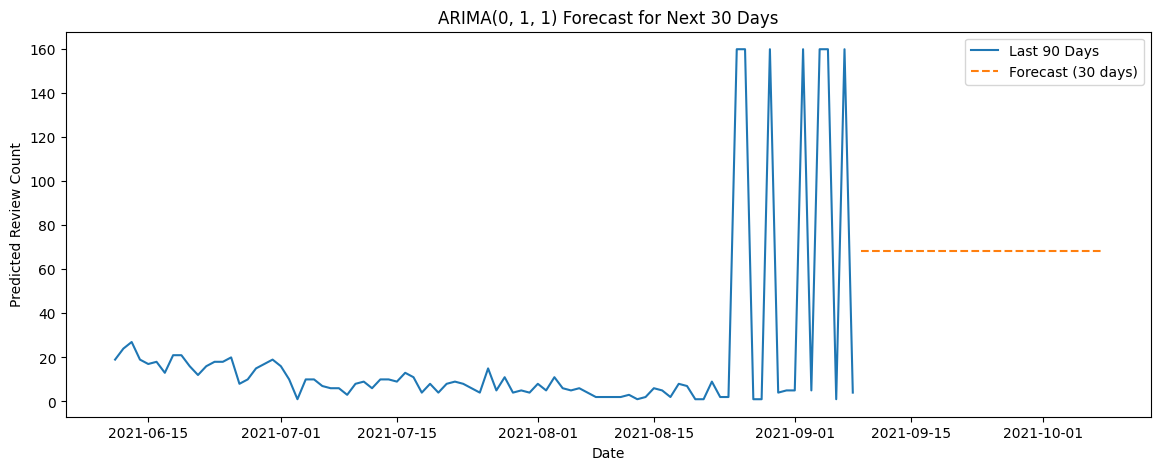

In [ ]:
# Forecast future 30 days with best model
# Refit the best model on the entire series

final_model = ARIMA(series, order=best_order).fit()

# Forecast the next 30 days
future_steps = 30
forecast = final_model.forecast(steps=future_steps)

# Create future date index
future_dates = pd.date_range(series.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='D')
forecast = pd.Series(forecast, index=future_dates)

# Plot recent data + forecast
plt.figure(figsize=(14, 5))
plt.plot(series[-90:], label='Last 90 Days')
plt.plot(forecast, label='Forecast (30 days)', linestyle='--')
plt.title(f"ARIMA{best_order} Forecast for Next {future_steps} Days")
plt.xlabel('Date')
plt.ylabel('Predicted Review Count')
plt.legend()
plt.show()

The solid line represents the last 30 days of actual data, highlighting recent trends.

The dashed line shows the forecast, which appears relatively stable and flat, reflecting the model’s expectation of steady activity in the short term.
This projection is derived from the best-fit ARIMA(0, 1, 1) model, which achieved the lowest MAE of 38.078133 during grid search over 27 parameter combinations.

The ARIMA forecast provides actionable insights for short-term planning and resource allocation, giving an evidence-based estimate of future review volumes.




In [ ]:
#Top results summary tabl
# Sort results by MAE
results_df = pd.DataFrame(results, columns=['(p,d,q)', 'MAE'])
results_df = results_df.sort_values('MAE').reset_index(drop=True)
print("📊 Top 5 ARIMA combinations:")
display(results_df.head(5))

📊 Top 5 ARIMA combinations:


,"(p,d,q)",MAE
0,"(0, 1, 1)",38.078133
1,"(2, 1, 1)",38.093878
2,"(2, 1, 2)",38.094339
3,"(1, 1, 2)",38.100502
4,"(1, 1, 1)",38.103562


2.3 answer below






In [ ]:
!pip install pdf2image
!pip install pytesseract

In [ ]:
from pdf2image import convert_from_path
import pytesseract

pdf_path = "/content/drive/MyDrive/end term data/UA_Indigenous_Strategy_Annual_Report_May-2022.pdf"

pages = convert_from_path(pdf_path, dpi=300)
for i, page in enumerate(pages):
    text = pytesseract.image_to_string(page)
    print(f"Page {i+1} text:\n", text[:500])  # preview first 500 char

Page 1 text:
 UNIVERSITIES AUSTRALIA

Indigenous Strategy
annual report

MAY 2022

 

 

 

UNIVERSITIES
h\ AUSTRALIA

Page 2 text:
 K\|

This work is licensed under a Creative Commons Attribution 4.0 International License.

1 Geils Court Deakin ACT 2600

Ph: +61 (0)2 6285 8100

Fax: +61 (0)2 6285 810

Email: contact@universitiesaustralia.edu.au

universitiesaustralia.edu.au

ABN 53 008 502 930

 

Page 3 text:
 Contents

at

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

Foreword 4
Executive summary 5
Overview. 6
Context 7
Higher education data 8
Indigenous student enrolments 9
Field of education 11
Course level 12
Indigenous undergraduate applications 13
Indigenous student award course completions and completion rates 16
Indigenous employment outcomes 20
Indigenous academic and non-academic workforce 22
Comparisons to non-Indigenous staff 25
Indigenous staff — population parity. 29
The
Page 4 text:
 Foreword

Universities Australia and its 39 members are
committed t

In [ ]:
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.11 [186 kB]
Fetched 186 kB in 1s (280 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.11_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.11) ...
Setting up poppler-utils (22.02.0-2ubuntu0.11) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!pip install pdf2image pytesseract

In [ ]:
from pdf2image import convert_from_path
import pytesseract

pdf_path = "/content/drive/MyDrive/end term data/UA_Indigenous_Strategy_Annual_Report_May-2022.pdf"
ocr_text_path = "OCR_Output.txt"

pages = convert_from_path(pdf_path, dpi=300)
full_text = ""

for i, page in enumerate(pages):
    text = pytesseract.image_to_string(page)
    full_text += text + "\n"

# Save OCR text to file
with open(ocr_text_path, "w", encoding="utf-8") as f:
    f.write(full_text)

In [ ]:
# Read the OCR output automatically
with open("OCR_Output.txt", "r", encoding="utf-8") as f:
    ocr_text = f.read()

# Now ocr_text contains all the OCR content
print(ocr_text[:500])

UNIVERSITIES AUSTRALIA

Indigenous Strategy
annual report

MAY 2022

 

 

 

UNIVERSITIES
h\ AUSTRALIA

K\|

This work is licensed under a Creative Commons Attribution 4.0 International License.

1 Geils Court Deakin ACT 2600

Ph: +61 (0)2 6285 8100

Fax: +61 (0)2 6285 810

Email: contact@universitiesaustralia.edu.au

universitiesaustralia.edu.au

ABN 53 008 502 930

 

Contents

at

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

Foreword 4
Executive summary 5
Overview. 6
Cont


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Read OCR Text File

ocr_text_path = "OCR_Output.txt"

with open(ocr_text_path, "r", encoding="utf-8") as f:
    ocr_text = f.read()

In [ ]:
# 2. Initialize Lists for Structured Data

metrics = []
subcategories = []
years = []
values = []


# Parse "from X in YYYY to Y in YYYY" patterns

pattern_range = re.compile(r'from ([\d,]+) in (\d{4}) to ([\d,]+) in (\d{4})')
for match in pattern_range.finditer(ocr_text):
    start_val, start_year, end_val, end_year = match.groups()
    metrics.append("Indigenous Student Enrolments")
    subcategories.append(None)
    years.append(int(start_year))
    values.append(int(start_val.replace(',', '')))

    metrics.append("Indigenous Student Enrolments")
    subcategories.append(None)
    years.append(int(end_year))
    values.append(int(end_val.replace(',', '')))

In [ ]:
# Parse Percentages

pattern_percent = re.compile(r'(\d+(?:\.\d+)?) per cent')
for match in pattern_percent.finditer(ocr_text):
    val = float(match.group(1))
    # Guess metric based on surrounding text (optional: manually refine)
    metrics.append("Percentage Metric")
    subcategories.append(None)
    years.append(None)
    values.append(val)

In [ ]:
# Parse Field of Education Percentages

field_pattern = re.compile(r'([a-zA-Z &]+)\s*\(?(\d+(?:\.\d+)?)\s*%\)?')
for match in field_pattern.finditer(ocr_text):
    field, val = match.groups()
    metrics.append("Field of Education Enrolments (%)")
    subcategories.append(field.strip().title())
    years.append(None)  # You can assign years if extracted separately
    values.append(float(val))


In [ ]:
#  Build DataFrame

df = pd.DataFrame({
    "Metric": metrics,
    "Subcategory": subcategories,
    "Year": years,
    "Value": values
})

print("Preview of Structured Data:")
print(df.head(20))

Preview of Structured Data:
                           Metric Subcategory    Year   Value
0   Indigenous Student Enrolments        None  2008.0   33.00
1   Indigenous Student Enrolments        None  2020.0   71.00
2   Indigenous Student Enrolments        None  2005.0  282.00
3   Indigenous Student Enrolments        None  2021.0  619.00
4               Percentage Metric        None     NaN    7.60
5               Percentage Metric        None     NaN    1.25
6               Percentage Metric        None     NaN    2.04
7               Percentage Metric        None     NaN    6.90
8               Percentage Metric        None     NaN   32.20
9               Percentage Metric        None     NaN   24.60
10              Percentage Metric        None     NaN   19.40
11              Percentage Metric        None     NaN   15.40
12              Percentage Metric        None     NaN    8.90
13              Percentage Metric        None     NaN    5.60
14              Percentage Metric        N

In [ ]:
def classify_metric(value):
    if value in [1.25, 2.04]:
        return "Proportion of Indigenous Students (%)"
    elif 30 <= value <= 40 or 20 <= value <= 25 or 5 <= value <= 15:
        return "Field of Education Enrolments (%)"
    elif value in [7.6, 6.9]:
        return "Enrolment Growth Rate (%)"
    elif value in [1.6, 2.3, 5.8]:
        return "Age Group Distribution (%)"
    elif value in [2.4, 7.9, 3.3]:
        return "Application Growth (%)"
    else:
        return "Other/Noise"

df['Metric'] = df.apply(
    lambda row: "Indigenous Student Enrolments" if row['Metric'] == "Indigenous Student Enrolments"
    else classify_metric(row['Value']), axis=1)

print(df['Metric'].value_counts())


Metric
Other/Noise                              146
Field of Education Enrolments (%)         68
Application Growth (%)                     6
Indigenous Student Enrolments              4
Proportion of Indigenous Students (%)      4
Age Group Distribution (%)                 3
Name: count, dtype: int64


In [ ]:
#Clean out noise
df_clean = df[df['Metric'] != "Other/Noise"]

In [ ]:
print(df_clean['Metric'].value_counts())
print(df_clean.head(10))

Metric
Field of Education Enrolments (%)        68
Application Growth (%)                    6
Indigenous Student Enrolments             4
Proportion of Indigenous Students (%)     4
Age Group Distribution (%)                3
Name: count, dtype: int64
                                  Metric Subcategory    Year   Value
0          Indigenous Student Enrolments        None  2008.0   33.00
1          Indigenous Student Enrolments        None  2020.0   71.00
2          Indigenous Student Enrolments        None  2005.0  282.00
3          Indigenous Student Enrolments        None  2021.0  619.00
4      Field of Education Enrolments (%)        None     NaN    7.60
5  Proportion of Indigenous Students (%)        None     NaN    1.25
6  Proportion of Indigenous Students (%)        None     NaN    2.04
7      Field of Education Enrolments (%)        None     NaN    6.90
8      Field of Education Enrolments (%)        None     NaN   32.20
9      Field of Education Enrolments (%)        None     

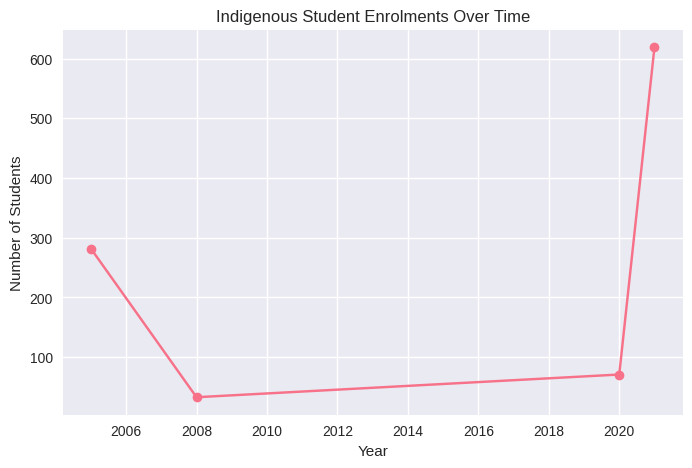

In [ ]:
indigenous_df = df_clean[df_clean['Metric'] == 'Indigenous Student Enrolments'].dropna(subset=['Year'])
indigenous_df = indigenous_df.sort_values('Year')

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(indigenous_df['Year'], indigenous_df['Value'], marker='o')
plt.title('Indigenous Student Enrolments Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Students')
plt.grid(True)
plt.show()


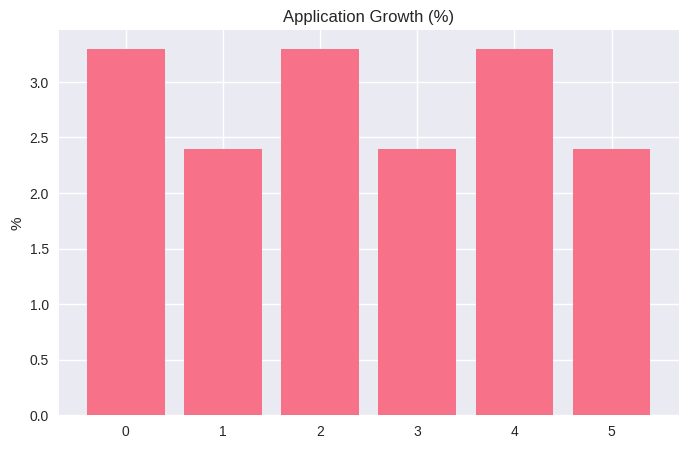

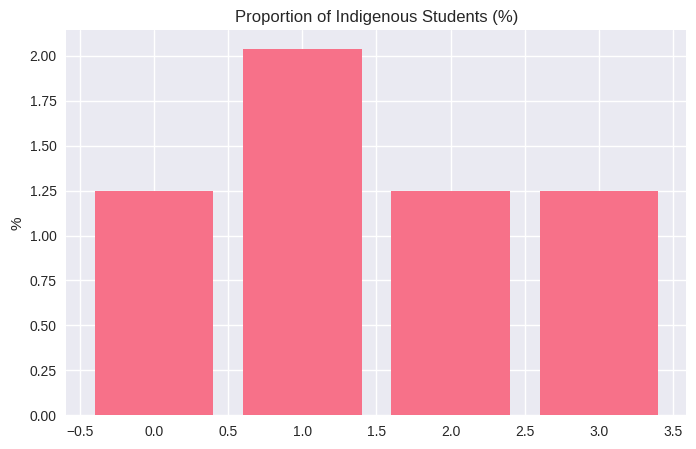

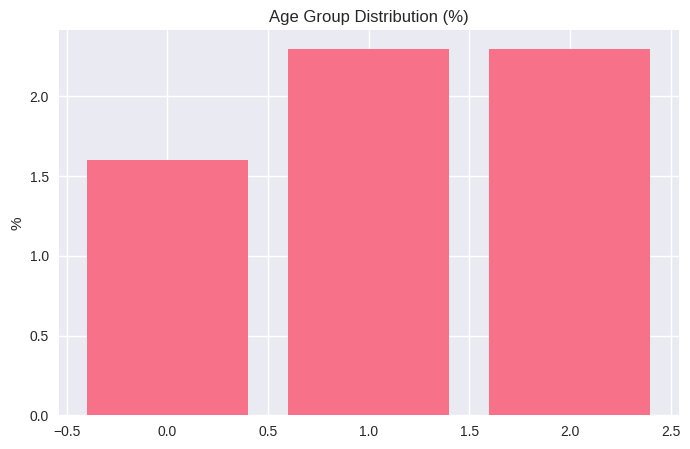

In [ ]:
app_df = df_clean[df_clean['Metric'] == 'Application Growth (%)']
prop_df = df_clean[df_clean['Metric'] == 'Proportion of Indigenous Students (%)']
age_df = df_clean[df_clean['Metric'] == 'Age Group Distribution (%)']

plt.figure(figsize=(8,5))
plt.bar(range(len(app_df)), app_df['Value'])
plt.title('Application Growth (%)')
plt.ylabel('%')
plt.show()

plt.figure(figsize=(8,5))
plt.bar(range(len(prop_df)), prop_df['Value'])
plt.title('Proportion of Indigenous Students (%)')
plt.ylabel('%')
plt.show()

plt.figure(figsize=(8,5))
plt.bar(range(len(age_df)), age_df['Value'])
plt.title('Age Group Distribution (%)')
plt.ylabel('%')
plt.show()

In [ ]:
summary = df_clean.groupby('Metric')['Value'].describe()
print(summary)

                                       count        mean         std    min  \
Metric                                                                        
Age Group Distribution (%)               3.0    2.066667    0.404145   1.60   
Application Growth (%)                   6.0    2.850000    0.492950   2.40   
Field of Education Enrolments (%)       68.0   16.227941   10.145344   5.30   
Indigenous Student Enrolments            4.0  251.250000  268.519863  33.00   
Proportion of Indigenous Students (%)    4.0    1.447500    0.395000   1.25   

                                          25%     50%       75%     max  
Metric                                                                   
Age Group Distribution (%)              1.950    2.30    2.3000    2.30  
Application Growth (%)                  2.400    2.85    3.3000    3.30  
Field of Education Enrolments (%)       7.825   11.30   23.4750   37.00  
Indigenous Student Enrolments          61.500  176.50  366.2500  619.00  
Pr

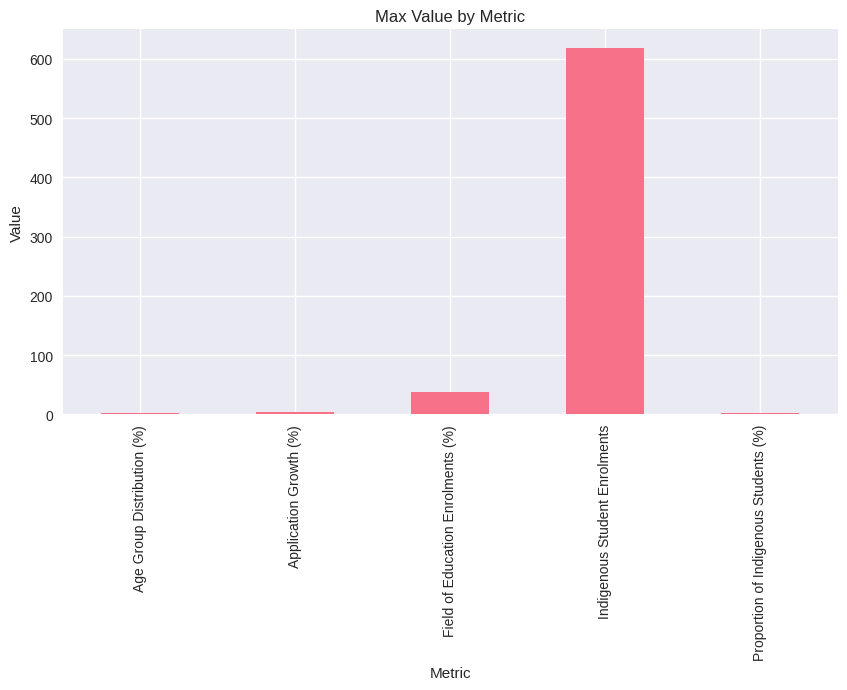

In [ ]:
summary['max'].plot(kind='bar', figsize=(10,5), title='Max Value by Metric')
plt.ylabel('Value')
plt.show()